# Hierarchical DDM regressions

 This tutorial walks you through fitting hierarchical Drift Diffusion Models (DDMs) with HSSM. If you're new to HSSM, please click this [link](https://lnccbrown.github.io/HSSM/getting_started/getting_started/). For background on hierarchical modeling in HSSM, please click this [link](https://lnccbrown.github.io/HSSM/getting_started/hierarchical_modeling/).
We'll move through four progressively more complex scenarios, each demonstrating a different real-world experimental design and the kind of regression formula you'd use to capture it.


Here are all 4 scenarios:

| Variant | Scenario | v formula |
|--|--|--|
| **A** | A *within-subject* experiment where each trial varies in difficulty. | `v ~ 1 + difficulty + (1 + difficulty \| participant_id)` |
| **B** | Same as A, but participants also differ in age (a *between-subject* factor). Age affects drift rate on top of the *within-subject* difficulty effect. | `v ~ 1 + age + difficulty + (1 + difficulty \| participant_id)` |
| **C** | Same as B, but with an *interaction*: the effect of difficulty on drift rate varies with age. | `v ~ 1 + age + difficulty + age:difficulty + (1 + difficulty \| participant_id)` |
| **D** | Same v regression as A, but now every remaining DDM parameter (a, z, t) gets its own per-participant random intercept — this is the "fully hierarchical" case. | (v same as A; full hierarchy on a, z, t) |

In Variants A–C the other parameters (a, z, t) are estimated globally (`param ~ 1`) — this keeps the focus on the v regression and makes sampling fast. Variant D shows what happens when we add hierarchy to every parameter, demonstrating the fully hierarchical case.

The common `v` intercept owns the reference-level baseline. Participant intercepts and slopes are zero-centered deviations around the common effects, which is the identifiable non-centered specification. The reference is difficulty 0 and, in variants with age, age 0 because both covariates remain on their original scales.

### Note

Each variant follows the same pattern: **simulate synthetic data with known parameter values, fit the model, then check whether we recovered the true parameters.** This is *parameter recovery* — the standard sanity check before applying a model to real data.

If you already have your own data to estimate, you can **skip the simulation steps and go straight to the model fitting**. But running the simulation to recovery loop on synthetic data first is always a good idea — it confirms your modelling pipeline can actually recover the parameters it's supposed to estimate before you trust its inferences on real data.

### Layout of each variant

1. Pick ground-truth coefficients and simulate synthetic data with the **do-operator**
2. Fit a HSSM model to that data
3. Model graph and posterior summary
4. Check parameter recovery and posterior predictive fit

In [1]:
import os
import tempfile
import warnings
from pathlib import Path


def _format_warning(message, category, filename, lineno, line=None):
    """Render saved warnings without machine-local file paths."""
    del filename, lineno, line
    return f"{category.__name__}: {message}\n"


warnings.formatwarning = _format_warning

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

import hssm
from hssm.param.parameterization_check import find_disconnected_free_rvs

COVARIATE_SEED = 11
VARIANT_RNG_SEEDS = {"A": 21, "B": 22, "C": 23, "D": 24}
SIMULATION_SEEDS = {"A": 31, "B": 32, "C": 33, "D": 34}
FIT_SEEDS = {"A": 41, "B": 42, "C": 43, "D": 44}
INITVAL_JITTER = 0.0
MAX_DIVERGENCE_FRACTION = 0.005
covariate_rng = np.random.default_rng(COVARIATE_SEED)
variant_rngs = {
    label: np.random.default_rng(seed) for label, seed in VARIANT_RNG_SEEDS.items()
}

FULL_RUN = os.environ.get("FULL_RUN", "0") == "1"

if FULL_RUN:
    n_participants = 10
    n_trials = 150
    ppc_samples = 20
    sample_kwargs = dict(draws=1_000, tune=500, chains=4, cores=2)
    validation_scope = "scientific recovery validation"
else:
    n_participants = 5
    n_trials = 80
    ppc_samples = 8
    sample_kwargs = dict(draws=300, tune=300, chains=2, cores=2)
    validation_scope = "execution and formula smoke check only"

sample_kwargs.update(
    target_accept=0.9,
    progressbar=False,
    omit_offsets=True,
)
print(
    f"Execution mode: {'FULL' if FULL_RUN else 'QUICK'} — {validation_scope}; "
    f"{n_participants} participants x {n_trials} trials, "
    f"{sample_kwargs['chains']} chains x "
    f"({sample_kwargs['tune']} tune + {sample_kwargs['draws']} draws)"
)


def assert_connected(label, model):
    """Fail when a free random variable does not inform the likelihood."""
    disconnected = find_disconnected_free_rvs(model.pymc_model)
    assert not disconnected, f"{label} disconnected free RVs: {disconnected}"
    print(f"{label}: all free random variables are connected")


def assert_two_choices(label, data):
    """Require both response choices in every simulated dataset."""
    choices = np.sort(data["response"].unique())
    assert choices.size == 2, f"{label} produced choices {choices.tolist()}"
    print(f"{label}: simulated choices {choices.tolist()}")


def validate_sampling(label, idata):
    """Apply mode-appropriate sampler health checks."""
    posterior = idata.posterior
    expected_chains = sample_kwargs["chains"]
    expected_draws = sample_kwargs["draws"]
    assert posterior.sizes["chain"] == expected_chains
    assert posterior.sizes["draw"] == expected_draws
    for variable in posterior.data_vars:
        assert np.isfinite(posterior[variable].values).all(), variable

    diagnostics = az.summary(
        idata,
        kind="diagnostics",
        round_to="none",
    )
    max_r_hat = float(diagnostics["r_hat"].dropna().max())
    min_bulk_ess = float(diagnostics["ess_bulk"].dropna().min())
    min_tail_ess = float(diagnostics["ess_tail"].dropna().min())
    divergences = int(idata.sample_stats["diverging"].sum().item())
    divergence_fraction = divergences / (expected_chains * expected_draws)
    print(
        f"{label}: divergences={divergences} "
        f"({divergence_fraction:.3%}), max r_hat={max_r_hat:.4f}, "
        f"min bulk/tail ESS={min_bulk_ess:.0f}/{min_tail_ess:.0f}"
    )
    if FULL_RUN:
        assert divergence_fraction <= MAX_DIVERGENCE_FRACTION, (
            f"{label}: divergence rate {divergence_fraction:.3%} exceeds "
            f"{MAX_DIVERGENCE_FRACTION:.1%}"
        )
        assert max_r_hat <= 1.01, f"{label}: max r_hat={max_r_hat:.4f}"
        assert min_bulk_ess >= 400, f"{label}: bulk ESS={min_bulk_ess:.0f}"
        assert min_tail_ess >= 400, f"{label}: tail ESS={min_tail_ess:.0f}"
    else:
        print(f"{label}: quick mode reports diagnostics without accepting recovery")


def validate_predictive(label, model):
    """Require the requested posterior-predictive draws per chain."""
    traces = model.traces
    assert traces is not None and "posterior_predictive" in traces
    predictive = traces.posterior_predictive
    assert predictive.sizes["chain"] == sample_kwargs["chains"]
    assert predictive.sizes["draw"] == ppc_samples
    print(f"{label}: {ppc_samples} posterior-predictive draws per chain")


def _truth_is_covered(posterior, truth):
    interval = np.asarray(az.hdi(posterior, prob=0.95).values)
    truth = np.asarray(truth)
    return (truth >= interval[..., 0]) & (truth <= interval[..., 1])


def validate_recovery(
    label, idata, scalar_truths, required_scalar_names, participant_truths
):
    """Report recovery in quick mode and enforce it in full mode."""
    scalar_coverage = {
        name: bool(_truth_is_covered(idata.posterior[name], truth))
        for name, truth in scalar_truths.items()
    }
    family_coverage = {
        name: np.asarray(_truth_is_covered(idata.posterior[name], truth))
        for name, truth in participant_truths.items()
    }
    participant_covered = sum(int(values.sum()) for values in family_coverage.values())
    participant_total = sum(values.size for values in family_coverage.values())
    print(f"{label}: scalar 95% HDI coverage {scalar_coverage}")
    print(
        f"{label}: participant 95% HDI coverage "
        + ", ".join(
            f"{name}={int(values.sum())}/{values.size}"
            for name, values in family_coverage.items()
        )
        + f"; overall={participant_covered}/{participant_total}"
    )
    if FULL_RUN:
        missed_required = [
            name for name in required_scalar_names if not scalar_coverage[name]
        ]
        assert not missed_required, f"{label}: missed {missed_required}"
        for name, values in family_coverage.items():
            assert int(values.sum()) >= 8, f"{label} {name}: {values.sum()}/10"
        assert participant_covered / participant_total >= 0.90, (
            f"{label}: {participant_covered}/{participant_total}"
        )


# simulated-data checkpoints go to a temp dir, not the docs tree
SIM_DIR = Path(tempfile.mkdtemp(prefix="hssm_hierarchical_sim_"))
# JAX emits os.fork warnings under multiprocess sampling; harmless here
warnings.filterwarnings("ignore", message=".*os.fork.*")

Execution mode: FULL — scientific recovery validation; 10 participants x 150 trials, 4 chains x (500 tune + 1000 draws)


## Covariates

The published full run uses **10 participants** doing **150 trials each**, giving us 1500 trials total. Routine notebook CI uses a smaller 5-participant, 80-trial execution/formula smoke check; it reports sampler diagnostics but does not treat them as convergence or parameter-recovery evidence. Full mode allows at most a 0.5% divergence rate and still enforces R-hat, effective-sample-size, focal-effect recovery, group-scale recovery, and participant-effect coverage; it reports coverage for the remaining reference and nuisance scalars without treating simultaneous coverage of every 95% interval as a valid acceptance test. Set `FULL_RUN=1` to reproduce the scientifically validated full analysis and its committed outputs. Synthetic data and posterior fits use independent fixed seeds for each variant, and `initval_jitter=0` removes HSSM's otherwise unseeded constructor jitter so the fitted starting values are reproducible. HSSM's current posterior-predictive helper does not expose a seed, so the exact PPC simulations can vary while their draw count and qualitative checks remain fixed.

Two covariates are tracked throughout:

- `difficulty` — varies trial-by-trial (*within-subject*)
- `age` — one value per participant (*between-subject*)

`difficulty` is simulated on a 0-10 scale, and `age` is represented as participant age in years. The `rt` and `response` columns start as placeholders and get filled in after simulation.

In this synthetic setup, larger `difficulty` values have a positive population-average effect on drift rate. Participant-specific slopes may attenuate or reverse that effect. `age` is represented as participant age in years; older participants are assumed to have higher drift rates on average.


In [2]:
pid = np.repeat(np.arange(n_participants), n_trials)

# Trial-level difficulty on a readable 0-10 scale.
difficulty = covariate_rng.uniform(0, 10, size=n_participants * n_trials)

# Participant-level age in years.
age_by_p = covariate_rng.uniform(20, 75, size=n_participants)
age = age_by_p[pid]

covariates = pd.DataFrame(
    {
        "participant_id": pid,
        "difficulty": difficulty,
        "age": age,
        "rt": np.nan,
        "response": np.nan,
    }
)
covariates.head()

,participant_id,difficulty,age,rt,response
0,0,1.285702,56.725679,NaN,NaN
1,0,4.992779,56.725679,NaN,NaN
2,0,6.014984,56.725679,NaN,NaN
3,0,0.286890,56.725679,NaN,NaN
4,0,1.479261,56.725679,NaN,NaN


## Simulating synthetic data with the do-operator


### What is the do-operator doing?

It intervenes on the model's parameters by fixing them to specific values, then sample the likelihood to generate fresh `rt` / `response` data. The result is synthetic data that we know was generated from that exact parameter setting.

In code, this looks like `model.sample_do(params={...})`. We pass it a dictionary of parameter values and it returns a fresh dataset.

For a deeper walkthrough of `sample_do`, see the [HSSM do-operator tutorial](https://lnccbrown.github.io/HSSM/tutorials/do_operator/).


## Variant A: within-subject 

Each trial varies in `difficulty`. Each participant has their own baseline drift rate and their own sensitivity to difficulty.

Drift rate `v` depends on `difficulty`, and each participant gets their own intercept and slope.

The other parameters (`a`, `z`, `t`) are kept as global scalars - no per-participant variation, no regression. 

### Step 1: Simulate the data

We pick ground-truth values for the regression coefficients (e.g. `beta_v_difficulty = 0.08`), determine the per-participant random effects, and pass everything to the model via the do-operator. Outcomes are synthetic `rt`/`response` data that we know was generated from this exact parameter setting.

Because `a`, `z`, `t` are global scalars in this variant, we simulate them as scalars too.

In [3]:
# true coefficients for variant A
beta_v_intercept = 0.0
beta_v_difficulty = 0.08
sigma_v_int, sigma_v_slope = 0.3, 0.2

rng_A = variant_rngs["A"]
v_int_p = rng_A.normal(0, sigma_v_int, n_participants)
v_slope_p = rng_A.normal(0, sigma_v_slope, n_participants)
a_true, z_true, t_true = 1.2, 0.5, 0.25

# Noncentered offsets for the random effects
v_int_offset = v_int_p / sigma_v_int
v_slope_offset = v_slope_p / sigma_v_slope

# Build HSSM model with the regression formula
dummy_data = covariates.copy()
dummy_data["rt"] = 1.0
dummy_data["response"] = 1.0

model_A_gen = hssm.HSSM(
    data=dummy_data,
    model="ddm",
    global_formula="y ~ 1",
    include=[
        {
            "name": "v",
            "formula": "v ~ 1 + difficulty + (1 + difficulty | participant_id)",
        }
    ],
    noncentered=True,
    initval_jitter=INITVAL_JITTER,
)
assert_connected("Variant A generator", model_A_gen)

Model initialized successfully.


Variant A generator: all free random variables are connected


To see how HSSM relates to PyMC, please click this [link](https://lnccbrown.github.io/HSSM/archive/pymc_to_hssm/).

In [4]:
# Use do-operator
synth_idata_A, synth_model_A = model_A_gen.sample_do(
    params={
        "v_Intercept": beta_v_intercept,
        "v_difficulty": beta_v_difficulty,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_1|participant_id_offset": v_int_offset,
        "v_difficulty|participant_id_sigma": sigma_v_slope,
        "v_difficulty|participant_id_offset": v_slope_offset,
        "a_Intercept": a_true,
        "z_Intercept": z_true,
        "t_Intercept": t_true,
    },
    draws=1,
    var_names=["rt,response"],
    return_model=True,
    random_seed=SIMULATION_SEEDS["A"],
)

Sampling: [rt,response]


The graph below shows the response-generating part of the synthetic model after the do-operator has fixed the parameters used for simulation. For details on how PyMC renders model graphs, see the [`pm.model_to_graphviz` documentation](https://www.pymc.io/projects/docs/en/stable/api/model/generated/pymc.model_graph.model_to_graphviz.html).


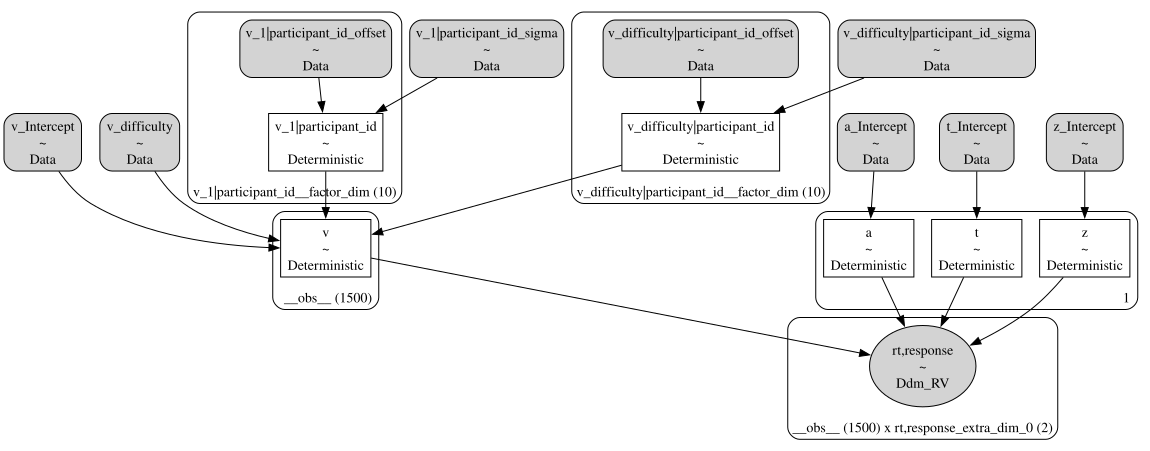

In [5]:
pm.model_to_graphviz(synth_model_A, var_names=["rt,response"])

The below cell converts simulated prior predictive outputs from the HSSM model into a DataFrame and extracts the generated reaction times (rt) and responses. It then merges these simulated outcomes with the original covariates to create a complete synthetic dataset and saves it as a CSV file.

In [6]:
synth_df_A = hssm.utils.predictive_dt_to_dataframe(
    synth_idata_A, predictive_group="prior_predictive"
)

data_A = covariates.copy()
data_A["rt"] = synth_df_A["rt"].values
data_A["response"] = synth_df_A["response"].values
assert_two_choices("Variant A", data_A)

data_A.to_csv(SIM_DIR / "sim_variant_A.csv", index=False)
data_A.head()

Variant A: simulated choices [-1.0, 1.0]


,participant_id,difficulty,age,rt,response
0,0,1.285702,56.725679,1.212994,-1.0
1,0,4.992779,56.725679,1.539058,1.0
2,0,6.014984,56.725679,2.088602,1.0
3,0,0.286890,56.725679,1.209743,-1.0
4,0,1.479261,56.725679,1.548914,-1.0


### Step 2: Fit a fresh HSSM model

Now we pretend we don't know the true parameters and try to recover them from the data. We reload the saved CSV, build a new HSSM model with the same regression structure, and explore the posterior.

In [7]:
data_A = pd.read_csv(SIM_DIR / "sim_variant_A.csv")

# Bin difficulty into 3 levels (low/med/high) for PPC plots
data_A["difficulty_level"] = pd.qcut(
    data_A["difficulty"], q=3, labels=["low", "med", "high"]
)

model_A = hssm.HSSM(
    data=data_A,
    model="ddm",
    global_formula="y ~ 1",
    include=[
        {
            "name": "v",
            "formula": "v ~ 1 + difficulty + (1 + difficulty | participant_id)",
        }
    ],
    noncentered=True,
    initval_jitter=INITVAL_JITTER,
)
assert_connected("Variant A fitted model", model_A)

Model initialized successfully.


Variant A fitted model: all free random variables are connected


#### Sanity check before sampling

`print(model)` shows every parameter's formula in text. The PyMC/Graphviz call below draws the response-generating subgraph, which is useful for checking that the regression structure and participant-level hierarchy feed into `rt,response` as expected. For details on PyMC model graphs, see the [`pm.model_to_graphviz` documentation](https://www.pymc.io/projects/docs/en/stable/api/model/generated/pymc.model_graph.model_to_graphviz.html).

For more example graphs across HSSM models, see the [Scientific Workflow tutorial](https://lnccbrown.github.io/HSSM/tutorials/scientific_workflow_hssm/).


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 1500

Parameters:

v:
    Formula: v ~ 1 + difficulty + (1 + difficulty | participant_id)
    Priors:
        v_Intercept ~ Normal(mu: 2.0, sigma: 3.0)
        v_difficulty ~ Normal(mu: 0.0, sigma: 0.25)
        v_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
        v_difficulty|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Formula: a ~ 1
    Priors:
        a_Intercept ~ Gamma(mu: 1.5, sigma: 0.75)
    Link: identity
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~ 1
    Priors:
        z_Intercept ~ Beta(alpha: 10.0, beta: 10.0)
    Link: identity
    Explicit bounds: (0.0, 1.0)

t:
    Formula: t ~ 1
    Priors:
        t_Intercept ~ Gamma(mu: 0.2, sigma: 0.2)
    Link: identity
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distrib

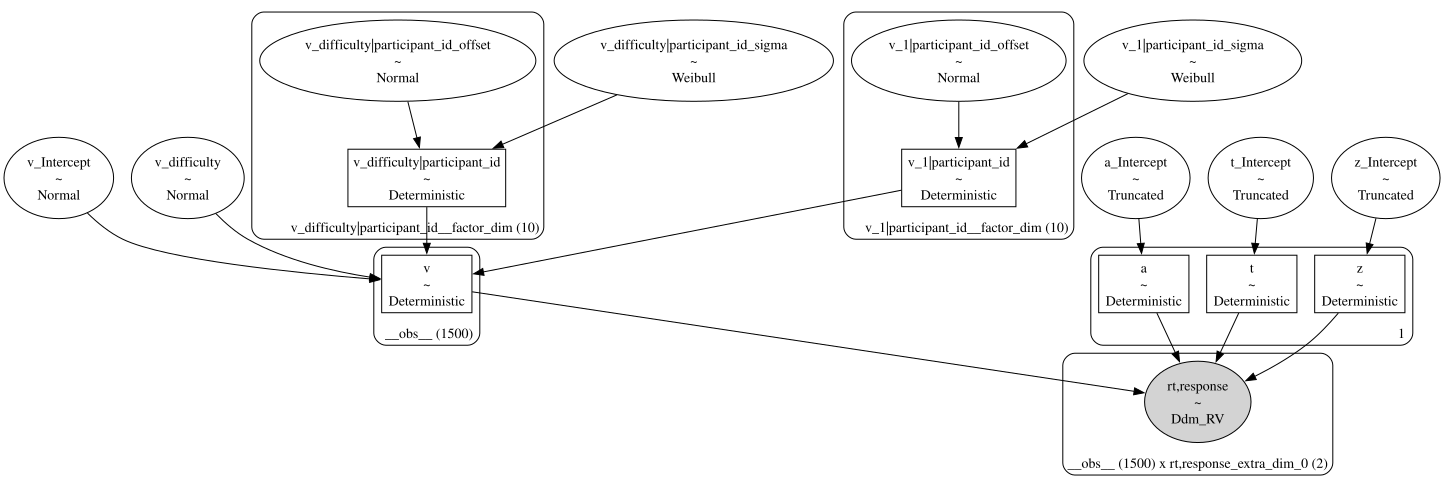

In [8]:
print(model_A)
pm.model_to_graphviz(model_A.pymc_model, var_names=["rt,response"])

In [9]:
idata_A = model_A.sample(
    random_seed=FIT_SEEDS["A"],
    idata_kwargs={"log_likelihood": False},
    **sample_kwargs,
)
validate_sampling("Variant A", idata_A)

Using default initvals. 



Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [v_Intercept, v_difficulty, v_1|participant_id_sigma, v_1|participant_id_offset, v_difficulty|participant_id_sigma, v_difficulty|participant_id_offset, a_Intercept, z_Intercept, t_Intercept]


Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 174 seconds.


Variant A: divergences=0 (0.000%), max r_hat=1.0076, min bulk/tail ESS=700/958


### Step 3: Inspect what got estimated
 
 First look at all estimated variables (no `var_names` filter) — this is how you discover the participant-wise parameters needed for recovery checks.

In [10]:
az.summary(idata_A)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_Intercept,-0.418,0.13,-0.63,-0.22,1659,2076,1.00,0.0032,0.0026
v_1|participant_id[0],0.079,0.166,-0.18,0.34,2264,2778,1.00,0.0035,0.0026
v_1|participant_id[1],0.411,0.189,0.12,0.73,2899,2913,1.00,0.0035,0.0025
v_1|participant_id[2],-0.498,0.205,-0.84,-0.19,2809,3058,1.00,0.0038,0.0029
v_1|participant_id[3],0.436,0.181,0.15,0.73,2795,3107,1.00,0.0034,0.0024
v_1|participant_id[4],0.045,0.177,-0.23,0.34,2361,2698,1.00,0.0036,0.0027
v_1|participant_id[5],-0.238,0.174,-0.51,0.032,2557,2774,1.00,0.0035,0.0027
v_1|participant_id[6],-0.298,0.193,-0.61,-0.0037,3004,2824,1.00,0.0035,0.0025
v_1|participant_id[7],-0.224,0.181,-0.52,0.058,2543,2742,1.00,0.0036,0.0027
v_1|participant_id[8],-0.068,0.188,-0.38,0.23,2706,2875,1.00,0.0036,0.0027



Now filter to the key global coefficients.

In [11]:
az.summary(idata_A, var_names=["~participant_id"], filter_vars="regex")

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_Intercept,-0.418,0.13,-0.63,-0.22,1659,2076,1.00,0.0032,0.0026
a_Intercept,1.2415,0.0221,1.2,1.3,4083,3378,1.00,0.00035,0.00024
t_Intercept,0.2547,0.0077,0.24,0.27,3805,3061,1.00,0.00012,8.8e-05
v_difficulty,0.139,0.088,-0.004,0.28,700,958,1.01,0.0033,0.0027
z_Intercept,0.5202,0.0094,0.5,0.53,5599,2894,1.00,0.00012,9e-05


`az.plot_trace` shows two views of each parameter side by side:

- **Left column** — the posterior *density*, one line per chain. 
- **Right column** — the *trace*: parameter value across posterior draws, shown separately for each chain.

For readability, the trace plots below focus on global/group-level parameters and omit participant-specific random effects; those participant-level effects are checked separately in the recovery plots.

For more on plotting in HSSM, please click this [link](https://lnccbrown.github.io/HSSM/tutorials/plotting/).


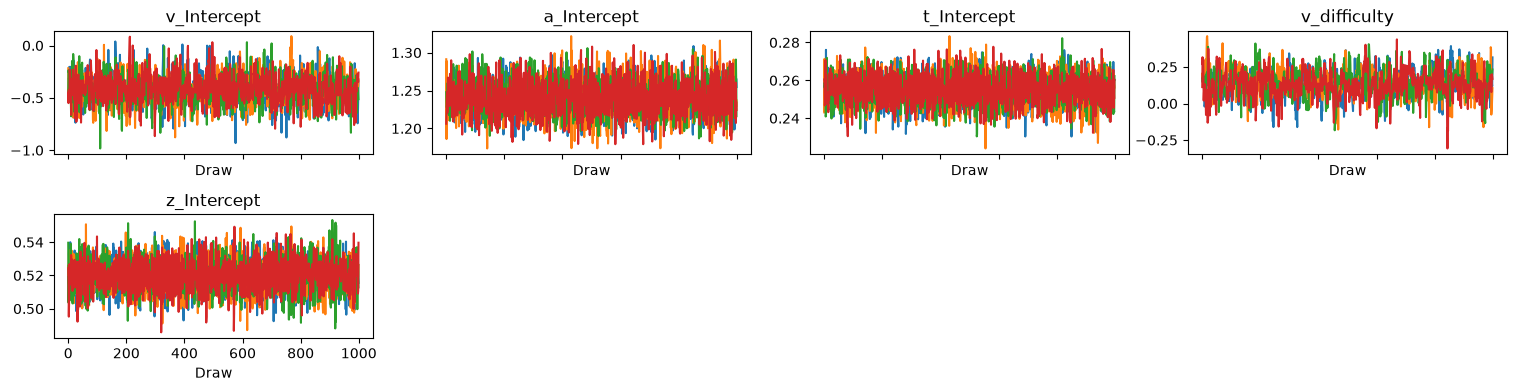

In [12]:
az.plot_trace(idata_A, var_names=["~participant_id"], filter_vars="regex")
plt.tight_layout()

### Step 4: Posterior predictive check

We sample many parameter sets from the posterior, forward-simulate `rt`/`response` data from each, and compare to what we observed. If the predicted distribution overlaps the observed one, the model is doing its job. If they diverge, the model is missing something.

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


Variant A: 20 posterior-predictive draws per chain


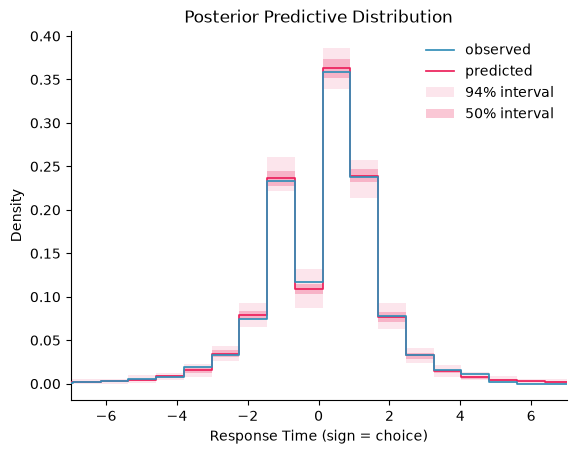

In [13]:
ax = hssm.plotting.plot_predictive(model_A, n_samples=ppc_samples, col_wrap=5)
ax.set_xlim(-7, 7)
validate_predictive("Variant A", model_A)

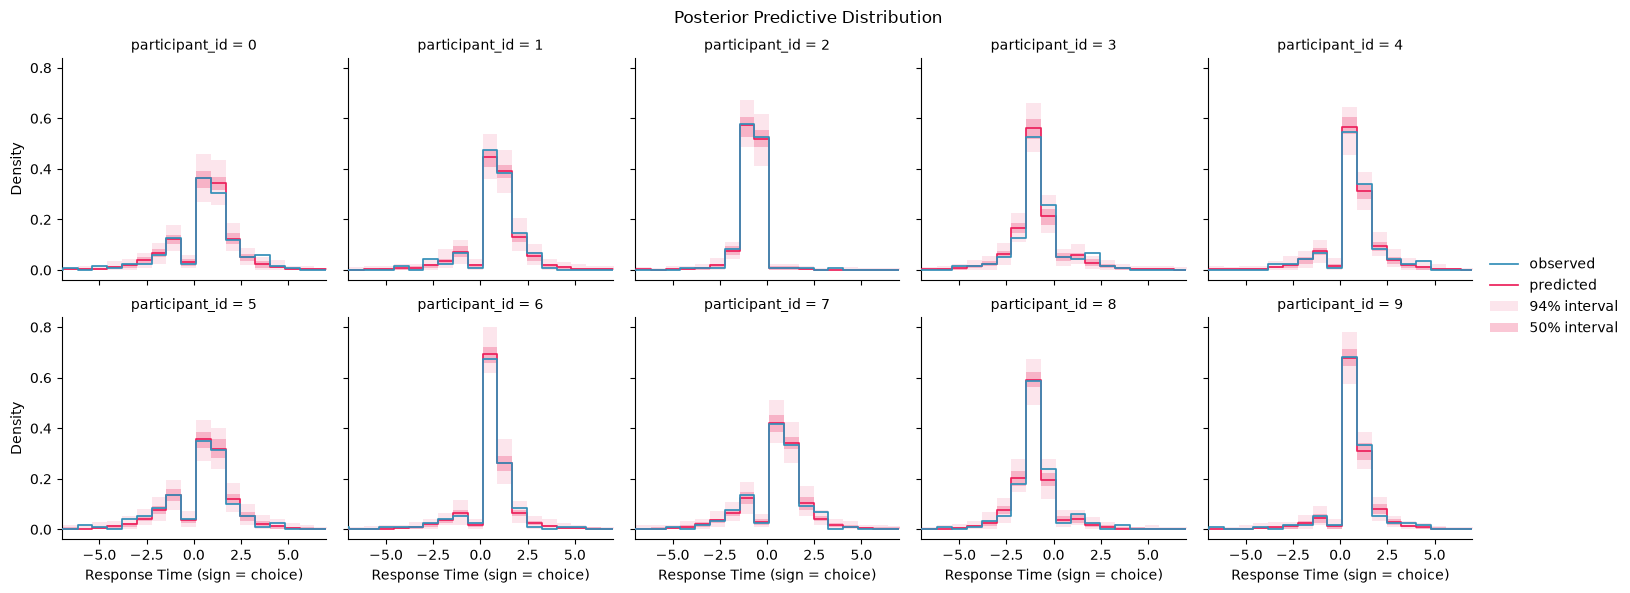

In [14]:
g = hssm.plotting.plot_predictive(
    model_A, n_samples=ppc_samples, col="participant_id", col_wrap=5
)
g.set(xlim=(-7, 7))

Variant A: scalar 95% HDI coverage {'v_Intercept': False, 'v_difficulty': True, 'v_1|participant_id_sigma': True, 'v_difficulty|participant_id_sigma': True, 'a_Intercept': True, 'z_Intercept': False, 't_Intercept': True}
Variant A: participant 95% HDI coverage v_1|participant_id=10/10, v_difficulty|participant_id=10/10; overall=20/20


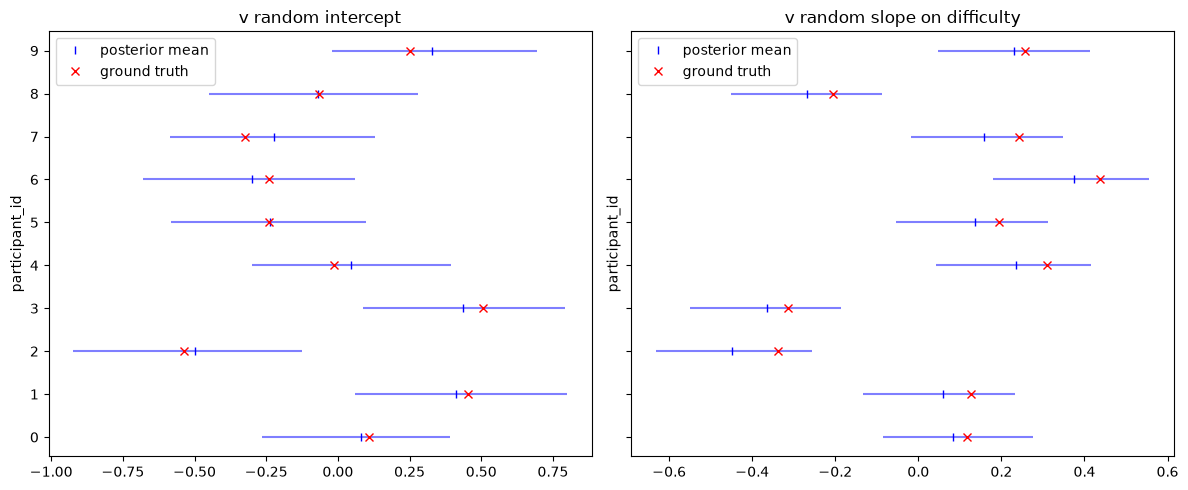

In [15]:
# Participant-wise parameter recovery for v (random intercepts and slopes)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey=True)

for ax, (param_name, truth, label) in zip(
    axes,
    [
        ("v_1|participant_id", v_int_p, "v random intercept"),
        ("v_difficulty|participant_id", v_slope_p, "v random slope on difficulty"),
    ],
):
    post = idata_A.posterior[param_name]
    mean = post.mean(dim=["chain", "draw"]).values
    hdi = az.hdi(post, prob=0.95).values

    yvals = np.arange(n_participants)
    ax.hlines(yvals, hdi[:, 0], hdi[:, 1], color="blue", alpha=0.5)
    ax.plot(mean, yvals, "|", color="blue", label="posterior mean")
    ax.plot(truth, yvals, "x", color="red", label="ground truth")
    ax.set_title(label)
    ax.set_yticks(yvals)
    ax.set_ylabel("participant_id")
    ax.legend()

plt.tight_layout()
validate_recovery(
    "Variant A",
    idata_A,
    scalar_truths={
        "v_Intercept": beta_v_intercept,
        "v_difficulty": beta_v_difficulty,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_difficulty|participant_id_sigma": sigma_v_slope,
        "a_Intercept": a_true,
        "z_Intercept": z_true,
        "t_Intercept": t_true,
    },
    required_scalar_names=(
        "v_difficulty",
        "v_1|participant_id_sigma",
        "v_difficulty|participant_id_sigma",
    ),
    participant_truths={
        "v_1|participant_id": v_int_p,
        "v_difficulty|participant_id": v_slope_p,
    },
)

Text(0.5, 0.98, '')

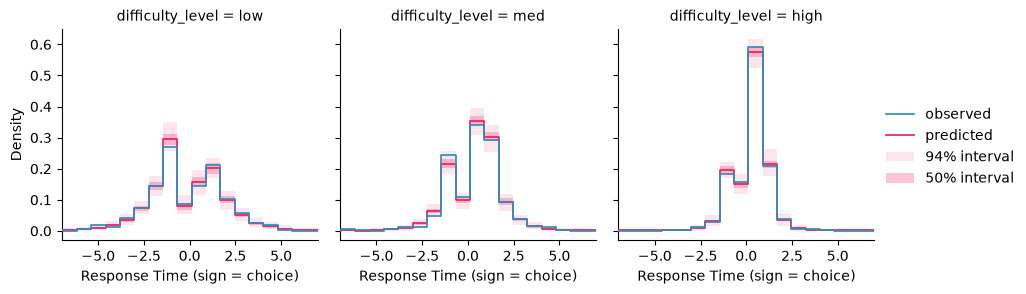

In [16]:
# Posterior predictive: split by difficulty level
g = hssm.plotting.plot_predictive(
    model_A, n_samples=ppc_samples, col="difficulty_level", col_wrap=3
)
g.set(xlim=(-7, 7))
g.fig.suptitle("")

## Variant B: between and within

Same within-subject difficulty effect as in Variant A, but now we also let `age` (a between-subject covariate) affect drift rate.

The `a`, `z`, `t` parameters remain global scalars.

### Step 1: Simulate the data

Model initialized successfully.


Sampling: [rt,response]


Variant B generator: all free random variables are connected


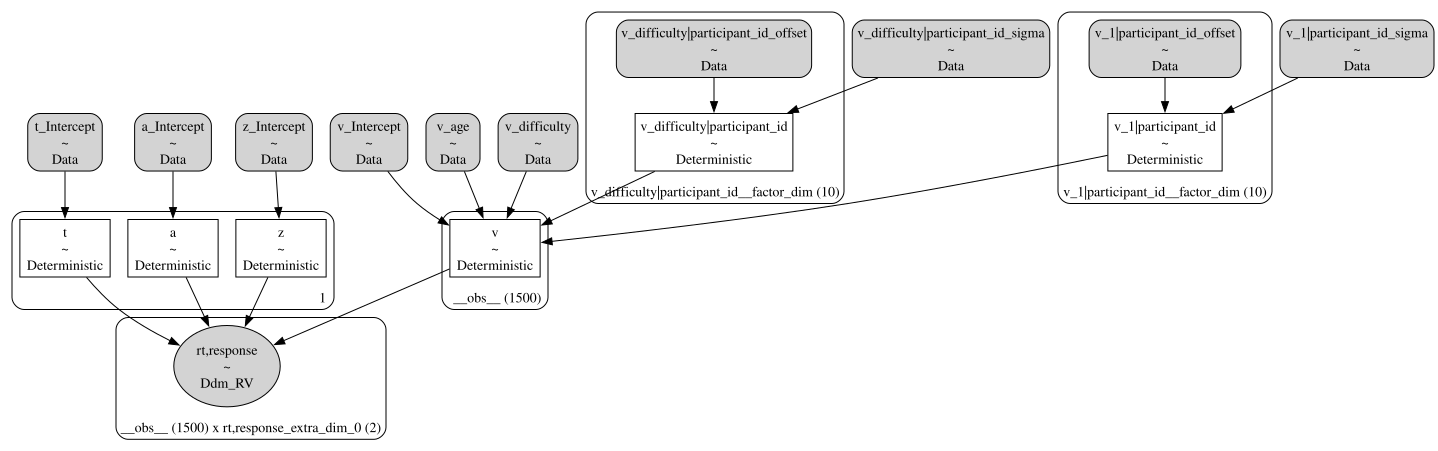

In [17]:
# true coefficients for variant B
beta_v_difficulty = 0.08
beta_v_age = 0.005

rng_B = variant_rngs["B"]
v_int_p = rng_B.normal(0, sigma_v_int, n_participants)
v_slope_p = rng_B.normal(0, sigma_v_slope, n_participants)

v_int_offset = v_int_p / sigma_v_int
v_slope_offset = v_slope_p / sigma_v_slope

# Build HSSM model with the regression formula
dummy_data = covariates.copy()
dummy_data["rt"] = 1.0
dummy_data["response"] = 1.0

model_B_gen = hssm.HSSM(
    data=dummy_data,
    model="ddm",
    global_formula="y ~ 1",
    include=[
        {
            "name": "v",
            "formula": "v ~ 1 + age + difficulty + (1 + difficulty | participant_id)",
        }
    ],
    noncentered=True,
    initval_jitter=INITVAL_JITTER,
)
assert_connected("Variant B generator", model_B_gen)

# Use do-operator: intervene on regression coefficients and random effects
synth_idata_B, synth_model_B = model_B_gen.sample_do(
    params={
        "v_Intercept": beta_v_intercept,
        "v_age": beta_v_age,
        "v_difficulty": beta_v_difficulty,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_1|participant_id_offset": v_int_offset,
        "v_difficulty|participant_id_sigma": sigma_v_slope,
        "v_difficulty|participant_id_offset": v_slope_offset,
        "a_Intercept": a_true,
        "z_Intercept": z_true,
        "t_Intercept": t_true,
    },
    draws=1,
    var_names=["rt,response"],
    return_model=True,
    random_seed=SIMULATION_SEEDS["B"],
)

pm.model_to_graphviz(synth_model_B, var_names=["rt,response"])

In [18]:
synth_df_B = hssm.utils.predictive_dt_to_dataframe(
    synth_idata_B, predictive_group="prior_predictive"
)

data_B = covariates.copy()
data_B["rt"] = synth_df_B["rt"].values
data_B["response"] = synth_df_B["response"].values
assert_two_choices("Variant B", data_B)
data_B.to_csv(SIM_DIR / "sim_variant_B.csv", index=False)

Variant B: simulated choices [-1.0, 1.0]


### Step 2: Fit a fresh HSSM model

In [19]:
data_B = pd.read_csv(SIM_DIR / "sim_variant_B.csv")

# Bin difficulty (3 levels) and age (3 levels) for faceted PPC plots
data_B["difficulty_level"] = pd.qcut(
    data_B["difficulty"], q=3, labels=["low", "med", "high"]
)
data_B["age_level"] = pd.qcut(data_B["age"], q=3, labels=["young", "middle", "older"])

model_B = hssm.HSSM(
    data=data_B,
    model="ddm",
    global_formula="y ~ 1",
    include=[
        {
            "name": "v",
            "formula": "v ~ 1 + age + difficulty + (1 + difficulty | participant_id)",
        }
    ],
    noncentered=True,
    initval_jitter=INITVAL_JITTER,
)
assert_connected("Variant B fitted model", model_B)

Model initialized successfully.


Variant B fitted model: all free random variables are connected


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 1500

Parameters:

v:
    Formula: v ~ 1 + age + difficulty + (1 + difficulty | participant_id)
    Priors:
        v_Intercept ~ Normal(mu: 2.0, sigma: 3.0)
        v_age ~ Normal(mu: 0.0, sigma: 0.25)
        v_difficulty ~ Normal(mu: 0.0, sigma: 0.25)
        v_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
        v_difficulty|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Formula: a ~ 1
    Priors:
        a_Intercept ~ Gamma(mu: 1.5, sigma: 0.75)
    Link: identity
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~ 1
    Priors:
        z_Intercept ~ Beta(alpha: 10.0, beta: 10.0)
    Link: identity
    Explicit bounds: (0.0, 1.0)

t:
    Formula: t ~ 1
    Priors:
        t_Intercept ~ Gamma(mu: 0.2, sigma: 0.2)
    Link: identity
    Explicit bounds:

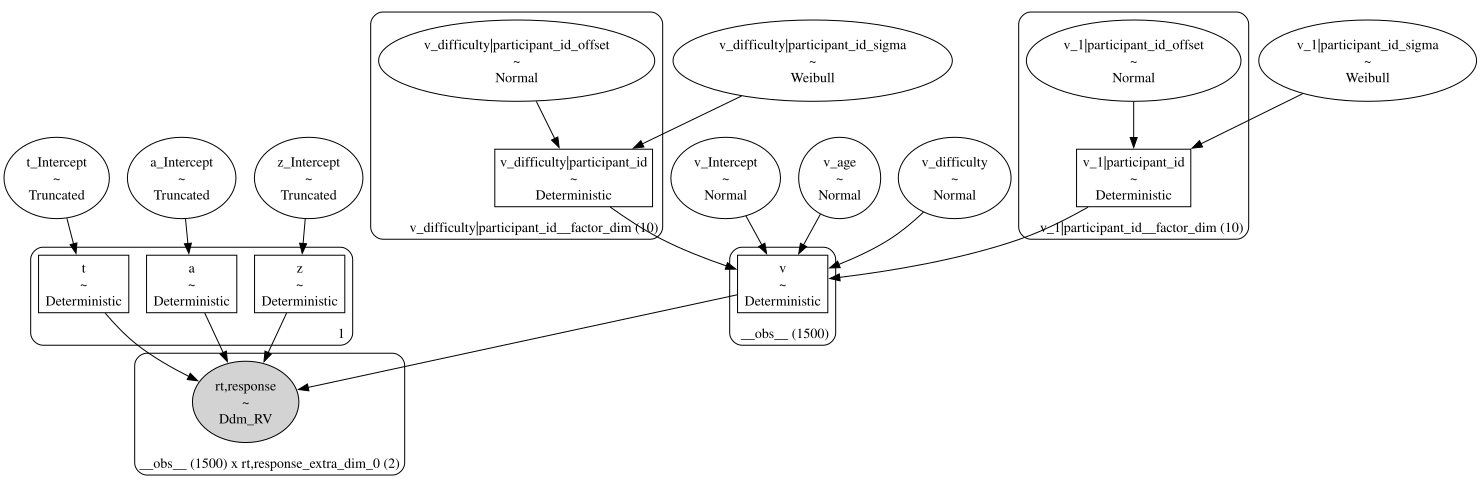

In [20]:
print(model_B)
pm.model_to_graphviz(model_B.pymc_model, var_names=["rt,response"])

In [21]:
idata_B = model_B.sample(
    random_seed=FIT_SEEDS["B"],
    idata_kwargs={"log_likelihood": False},
    **sample_kwargs,
)
validate_sampling("Variant B", idata_B)

Using default initvals. 



Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [v_Intercept, v_age, v_difficulty, v_1|participant_id_sigma, v_1|participant_id_offset, v_difficulty|participant_id_sigma, v_difficulty|participant_id_offset, a_Intercept, z_Intercept, t_Intercept]


Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 191 seconds.


Variant B: divergences=0 (0.000%), max r_hat=1.0020, min bulk/tail ESS=836/1231


### Step 3: Inspect what got estimated

In [22]:
az.summary(idata_B)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_Intercept,-0.74,0.42,-1.4,-0.074,1986,2114,1.00,0.0093,0.0074
v_1|participant_id[0],-0.152,0.18,-0.45,0.13,2585,2552,1.00,0.0036,0.0027
v_1|participant_id[1],-0.278,0.196,-0.6,0.023,3433,2873,1.00,0.0034,0.0026
v_1|participant_id[2],-0.383,0.247,-0.8,-0.01,2637,2719,1.00,0.0048,0.0037
v_1|participant_id[3],0.02,0.172,-0.25,0.31,2983,2758,1.00,0.0031,0.0024
v_1|participant_id[4],0.353,0.224,0.0029,0.71,2386,2471,1.00,0.0046,0.0035
v_1|participant_id[5],-0.331,0.209,-0.67,-0.015,2326,2519,1.00,0.0043,0.0034
v_1|participant_id[6],0.085,0.25,-0.3,0.5,2608,2749,1.00,0.0049,0.0039
v_1|participant_id[7],0.578,0.225,0.23,0.94,2613,2729,1.00,0.0044,0.0034
v_1|participant_id[8],0.073,0.188,-0.22,0.37,2537,2645,1.00,0.0038,0.0028


In [23]:
az.summary(idata_B, var_names=["~participant_id"], filter_vars="regex")

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_Intercept,-0.74,0.42,-1.4,-0.074,1986,2114,1.00,0.0093,0.0074
v_age,0.0061,0.0081,-0.0068,0.019,1892,2181,1.00,0.00019,0.00015
a_Intercept,1.232,0.0205,1.2,1.3,4134,2925,1.00,0.00032,0.00022
t_Intercept,0.2408,0.0086,0.23,0.25,4168,3242,1.00,0.00013,9.3e-05
v_difficulty,0.098,0.086,-0.044,0.23,835,1253,1.00,0.003,0.0025
z_Intercept,0.5093,0.0093,0.49,0.52,4946,2998,1.00,0.00013,9.4e-05


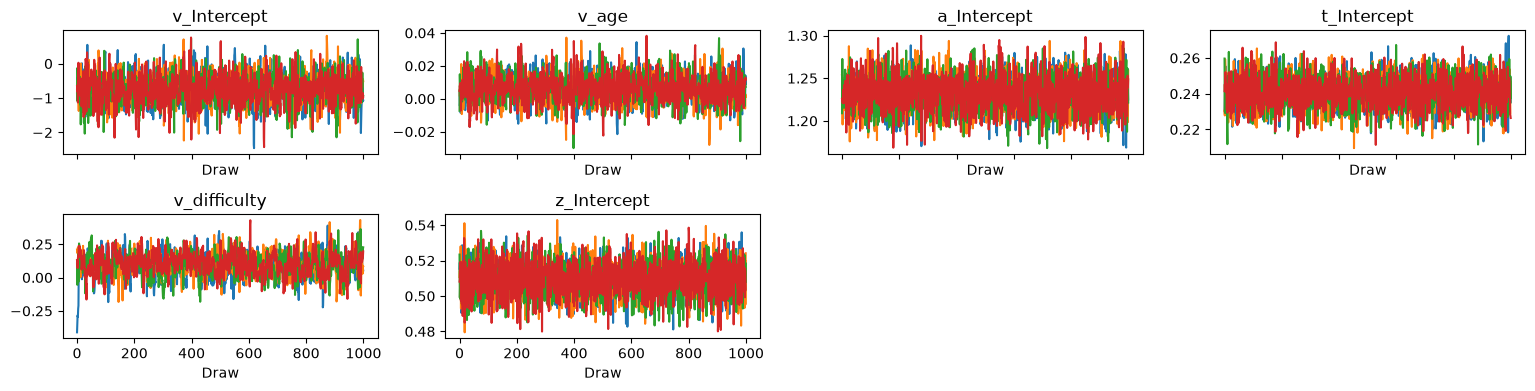

In [24]:
az.plot_trace(idata_B, var_names=["~participant_id"], filter_vars="regex")
plt.tight_layout()

### Step 4: Posterior predictive check

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


Variant B: 20 posterior-predictive draws per chain


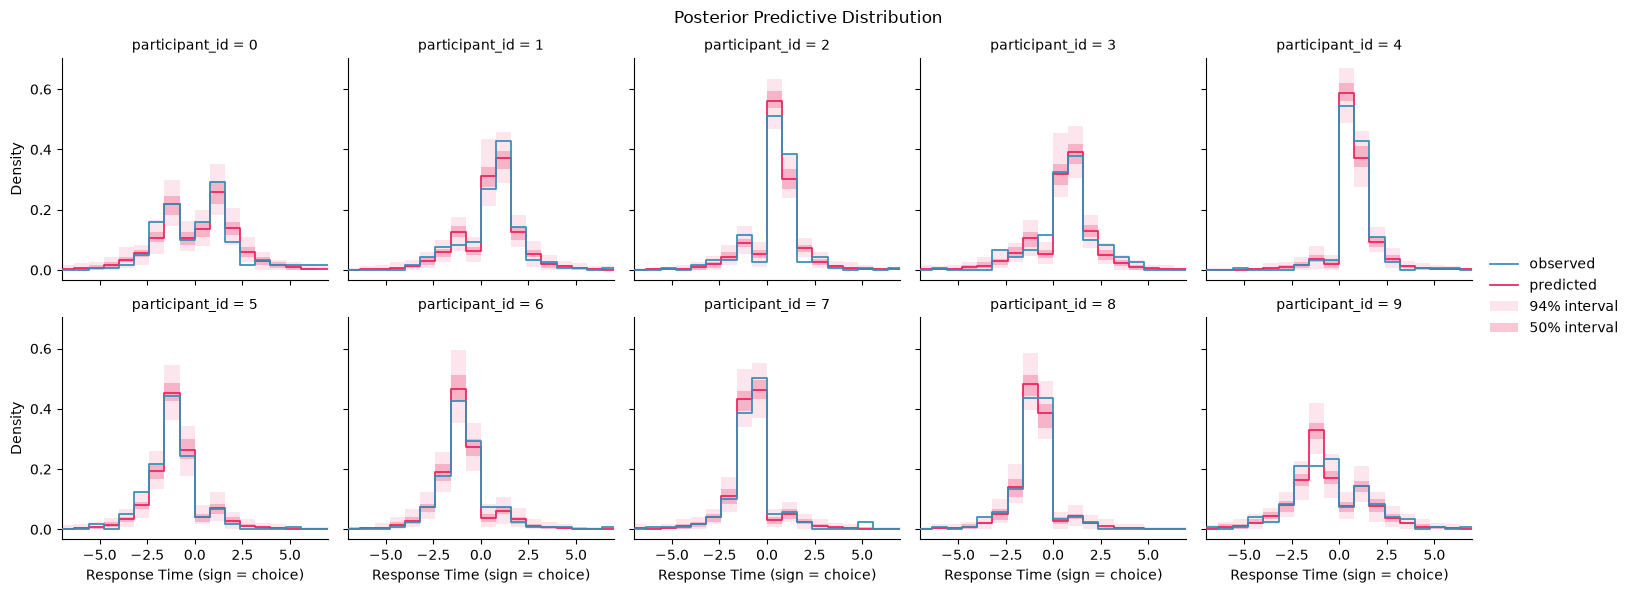

In [25]:
g = hssm.plotting.plot_predictive(
    model_B, n_samples=ppc_samples, col="participant_id", col_wrap=5
)
g.set(xlim=(-7, 7))
validate_predictive("Variant B", model_B)

Variant B: scalar 95% HDI coverage {'v_Intercept': True, 'v_age': True, 'v_difficulty': True, 'v_1|participant_id_sigma': True, 'v_difficulty|participant_id_sigma': True, 'a_Intercept': True, 'z_Intercept': True, 't_Intercept': True}
Variant B: participant 95% HDI coverage v_1|participant_id=10/10, v_difficulty|participant_id=10/10; overall=20/20


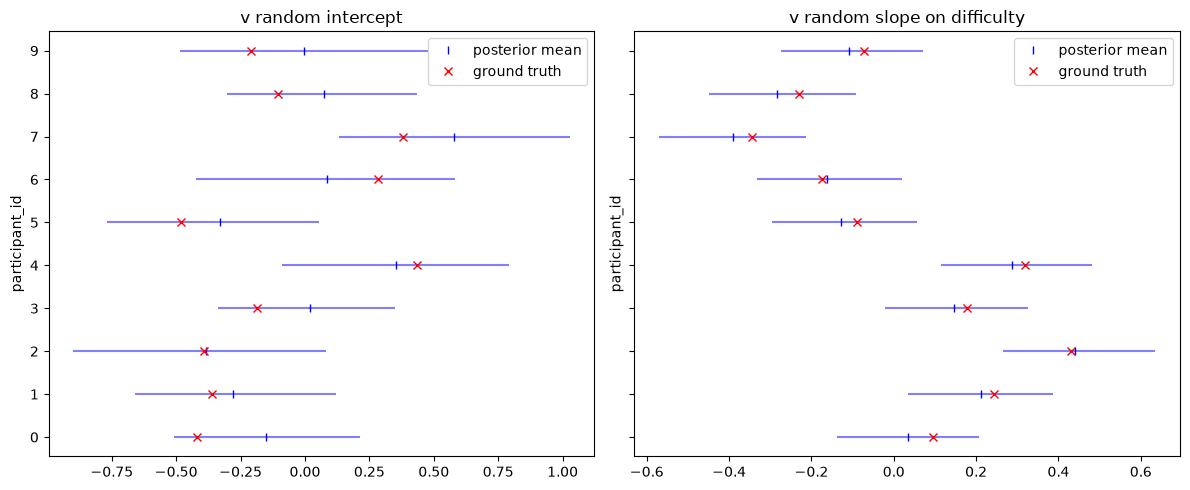

In [26]:
# Participant-wise parameter recovery for v (random intercepts and slopes)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey=True)

for ax, (param_name, truth, label) in zip(
    axes,
    [
        ("v_1|participant_id", v_int_p, "v random intercept"),
        ("v_difficulty|participant_id", v_slope_p, "v random slope on difficulty"),
    ],
):
    post = idata_B.posterior[param_name]
    mean = post.mean(dim=["chain", "draw"]).values
    hdi = az.hdi(post, prob=0.95).values

    yvals = np.arange(n_participants)
    ax.hlines(yvals, hdi[:, 0], hdi[:, 1], color="blue", alpha=0.5)
    ax.plot(mean, yvals, "|", color="blue", label="posterior mean")
    ax.plot(truth, yvals, "x", color="red", label="ground truth")
    ax.set_title(label)
    ax.set_yticks(yvals)
    ax.set_ylabel("participant_id")
    ax.legend()

plt.tight_layout()
validate_recovery(
    "Variant B",
    idata_B,
    scalar_truths={
        "v_Intercept": beta_v_intercept,
        "v_age": beta_v_age,
        "v_difficulty": beta_v_difficulty,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_difficulty|participant_id_sigma": sigma_v_slope,
        "a_Intercept": a_true,
        "z_Intercept": z_true,
        "t_Intercept": t_true,
    },
    required_scalar_names=(
        "v_age",
        "v_difficulty",
        "v_1|participant_id_sigma",
        "v_difficulty|participant_id_sigma",
    ),
    participant_truths={
        "v_1|participant_id": v_int_p,
        "v_difficulty|participant_id": v_slope_p,
    },
)

Text(0.5, 0.98, '')

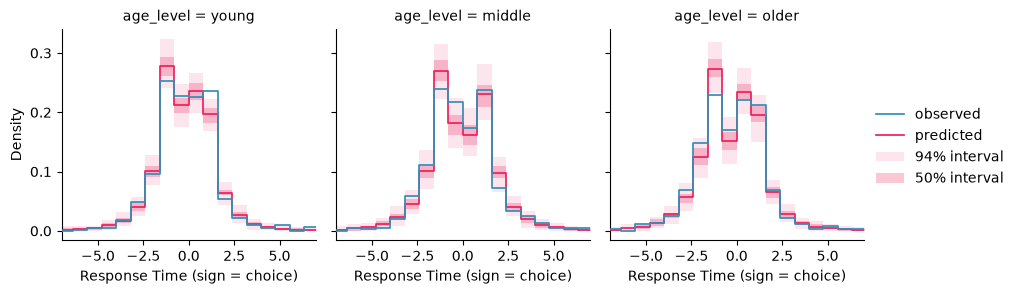

In [27]:
# Posterior predictive: split by age level (between-subject factor)
g = hssm.plotting.plot_predictive(
    model_B, n_samples=ppc_samples, col="age_level", col_wrap=3
)
g.set(xlim=(-7, 7))
g.fig.suptitle("")

Text(0.5, 0.98, '')

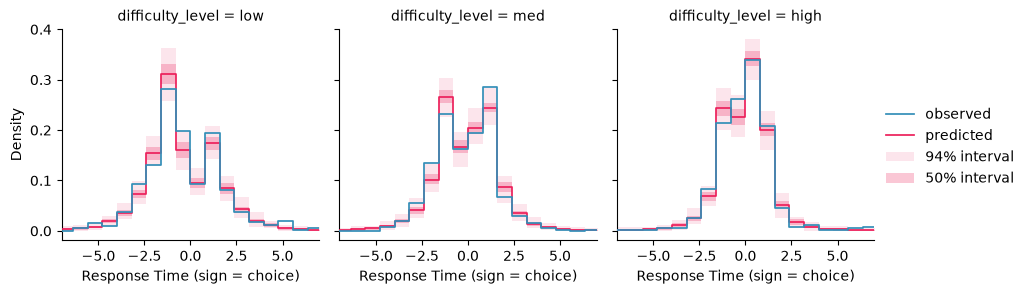

In [28]:
# Posterior predictive: split by difficulty level (within-subject factor)
g = hssm.plotting.plot_predictive(
    model_B, n_samples=ppc_samples, col="difficulty_level", col_wrap=3
)
g.set(xlim=(-7, 7))
g.fig.suptitle("")

## Variant C: interaction 

What if older and younger participants don't just differ in their baseline drift rate, but also in *how much* difficulty affects them? That's an **interaction** between `age` and `difficulty`.

To capture this, we add an `age:difficulty` term to the v regression. Same setup as Variant B otherwise.

### Step 1: Simulate the data

Model initialized successfully.


Sampling: [rt,response]


Variant C generator: all free random variables are connected


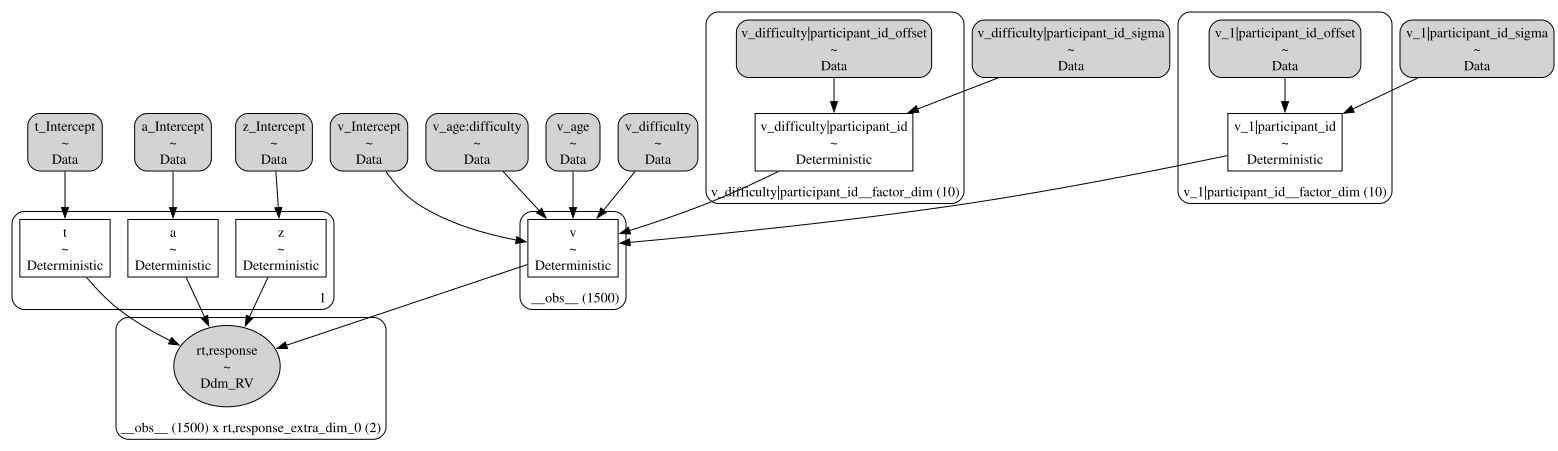

In [29]:
# true coefficients for variant C
beta_v_difficulty = 0.08
beta_v_age = 0.005
beta_v_age_difficulty = 0.0005

rng_C = variant_rngs["C"]
v_int_p = rng_C.normal(0, sigma_v_int, n_participants)
v_slope_p = rng_C.normal(0, sigma_v_slope, n_participants)

v_int_offset = v_int_p / sigma_v_int
v_slope_offset = v_slope_p / sigma_v_slope

# Build HSSM model with the regression formula
dummy_data = covariates.copy()
dummy_data["rt"] = 1.0
dummy_data["response"] = 1.0

model_C_gen = hssm.HSSM(
    data=dummy_data,
    model="ddm",
    global_formula="y ~ 1",
    include=[
        {
            "name": "v",
            "formula": (
                "v ~ 1 + age + difficulty + age:difficulty + "
                "(1 + difficulty | participant_id)"
            ),
        }
    ],
    noncentered=True,
    initval_jitter=INITVAL_JITTER,
)
assert_connected("Variant C generator", model_C_gen)

# Use do-operator: intervene on regression coefficients and random effects
synth_idata_C, synth_model_C = model_C_gen.sample_do(
    params={
        "v_Intercept": beta_v_intercept,
        "v_age": beta_v_age,
        "v_difficulty": beta_v_difficulty,
        "v_age:difficulty": beta_v_age_difficulty,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_1|participant_id_offset": v_int_offset,
        "v_difficulty|participant_id_sigma": sigma_v_slope,
        "v_difficulty|participant_id_offset": v_slope_offset,
        "a_Intercept": a_true,
        "z_Intercept": z_true,
        "t_Intercept": t_true,
    },
    draws=1,
    var_names=["rt,response"],
    return_model=True,
    random_seed=SIMULATION_SEEDS["C"],
)

pm.model_to_graphviz(synth_model_C, var_names=["rt,response"])

In [30]:
synth_df_C = hssm.utils.predictive_dt_to_dataframe(
    synth_idata_C, predictive_group="prior_predictive"
)

data_C = covariates.copy()
data_C["rt"] = synth_df_C["rt"].values
data_C["response"] = synth_df_C["response"].values
assert_two_choices("Variant C", data_C)
data_C.to_csv(SIM_DIR / "sim_variant_C.csv", index=False)

Variant C: simulated choices [-1.0, 1.0]


### Step 2: Fit a fresh HSSM model

In [31]:
data_C = pd.read_csv(SIM_DIR / "sim_variant_C.csv")

# Bin difficulty (3 levels) and age (3 levels) for faceted PPC plots
data_C["difficulty_level"] = pd.qcut(
    data_C["difficulty"], q=3, labels=["low", "med", "high"]
)
data_C["age_level"] = pd.qcut(data_C["age"], q=3, labels=["young", "middle", "older"])

model_C = hssm.HSSM(
    data=data_C,
    model="ddm",
    global_formula="y ~ 1",
    include=[
        {
            "name": "v",
            "formula": (
                "v ~ 1 + age + difficulty + age:difficulty + "
                "(1 + difficulty | participant_id)"
            ),
        }
    ],
    noncentered=True,
    initval_jitter=INITVAL_JITTER,
)
assert_connected("Variant C fitted model", model_C)

Model initialized successfully.


Variant C fitted model: all free random variables are connected


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 1500

Parameters:

v:
    Formula: v ~ 1 + age + difficulty + age:difficulty + (1 + difficulty | participant_id)
    Priors:
        v_Intercept ~ Normal(mu: 2.0, sigma: 3.0)
        v_age ~ Normal(mu: 0.0, sigma: 0.25)
        v_difficulty ~ Normal(mu: 0.0, sigma: 0.25)
        v_age:difficulty ~ Normal(mu: 0.0, sigma: 0.25)
        v_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
        v_difficulty|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Formula: a ~ 1
    Priors:
        a_Intercept ~ Gamma(mu: 1.5, sigma: 0.75)
    Link: identity
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~ 1
    Priors:
        z_Intercept ~ Beta(alpha: 10.0, beta: 10.0)
    Link: identity
    Explicit bounds: (0.0, 1.0)

t:
    Formula: t ~ 1
    Priors:
        t_Inter

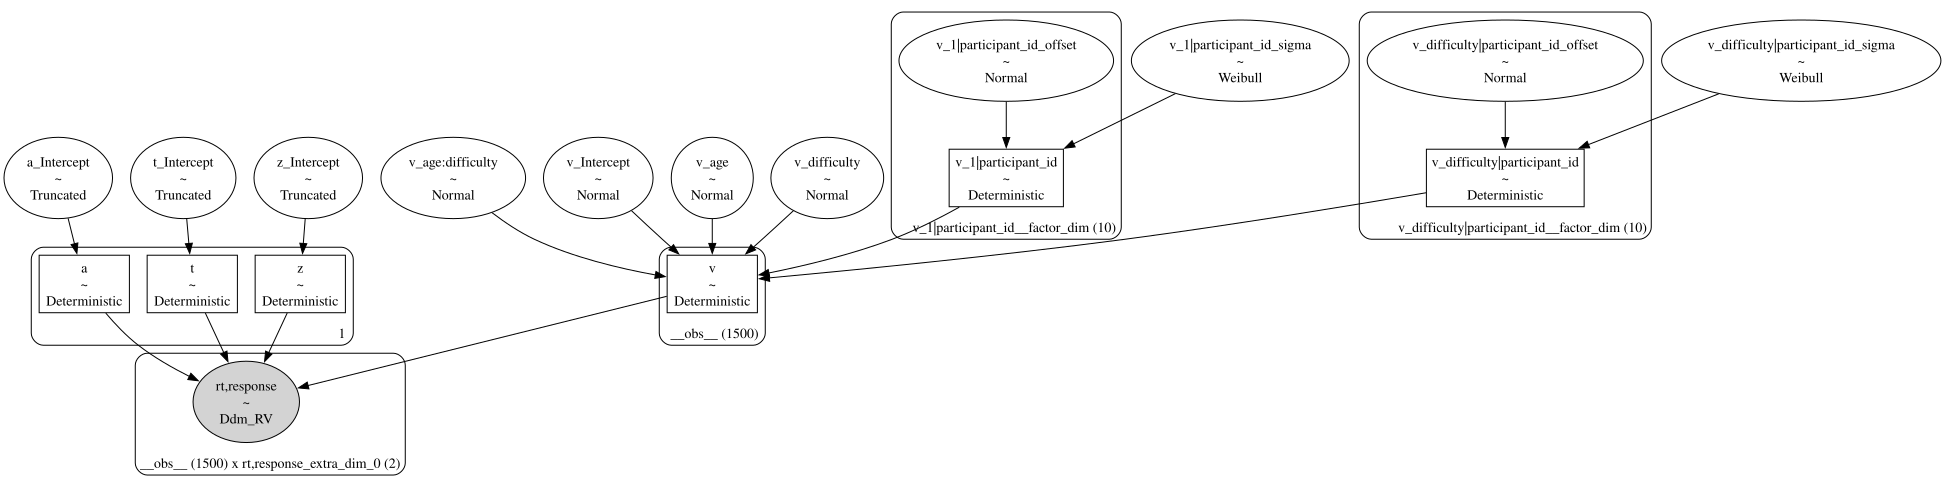

In [32]:
print(model_C)
pm.model_to_graphviz(model_C.pymc_model, var_names=["rt,response"])

In [33]:
idata_C = model_C.sample(
    random_seed=FIT_SEEDS["C"],
    idata_kwargs={"log_likelihood": False},
    **sample_kwargs,
)
validate_sampling("Variant C", idata_C)

Using default initvals. 



Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [v_Intercept, v_age, v_difficulty, v_age:difficulty, v_1|participant_id_sigma, v_1|participant_id_offset, v_difficulty|participant_id_sigma, v_difficulty|participant_id_offset, a_Intercept, z_Intercept, t_Intercept]


Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 271 seconds.


Variant C: divergences=0 (0.000%), max r_hat=1.0042, min bulk/tail ESS=1384/1378


### Step 3: Inspect what got estimated

In [34]:
az.summary(idata_C)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_Intercept,-0.7,0.46,-1.4,0.016,2211,2354,1.00,0.0097,0.0081
v_age:difficulty,0.0022,0.0027,-0.0022,0.0064,1490,2033,1.00,7e-05,5.2e-05
v_1|participant_id[0],0.254,0.193,-0.056,0.56,2454,2576,1.00,0.0039,0.003
v_1|participant_id[1],0.022,0.204,-0.3,0.35,2830,3042,1.00,0.0038,0.003
v_1|participant_id[2],-0.04,0.269,-0.48,0.38,2540,2582,1.00,0.0053,0.0043
v_1|participant_id[3],-0.791,0.207,-1.1,-0.48,2881,3014,1.00,0.0039,0.0028
v_1|participant_id[4],0.278,0.232,-0.091,0.64,2222,2662,1.00,0.0049,0.0038
v_1|participant_id[5],-0.57,0.23,-0.95,-0.22,2294,2639,1.00,0.0048,0.0036
v_1|participant_id[6],0.19,0.272,-0.23,0.62,2668,2896,1.00,0.0053,0.0043
v_1|participant_id[7],0.214,0.241,-0.16,0.59,2591,2976,1.00,0.0047,0.0038


In [35]:
az.summary(idata_C, var_names=["~participant_id"], filter_vars="regex")

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_Intercept,-0.7,0.46,-1.4,0.016,2211,2354,1.00,0.0097,0.0081
v_age:difficulty,0.0022,0.0027,-0.0022,0.0064,1490,2033,1.00,7e-05,5.2e-05
v_age,0.003,0.0088,-0.011,0.017,2160,2288,1.00,0.00019,0.00015
a_Intercept,1.2155,0.0182,1.2,1.2,4053,2999,1.00,0.00029,0.0002
t_Intercept,0.2474,0.0098,0.23,0.26,3568,2737,1.00,0.00017,0.00013
v_difficulty,-0.019,0.136,-0.24,0.19,1613,1983,1.00,0.0034,0.0026
z_Intercept,0.5059,0.0092,0.49,0.52,4757,3307,1.00,0.00013,9.6e-05


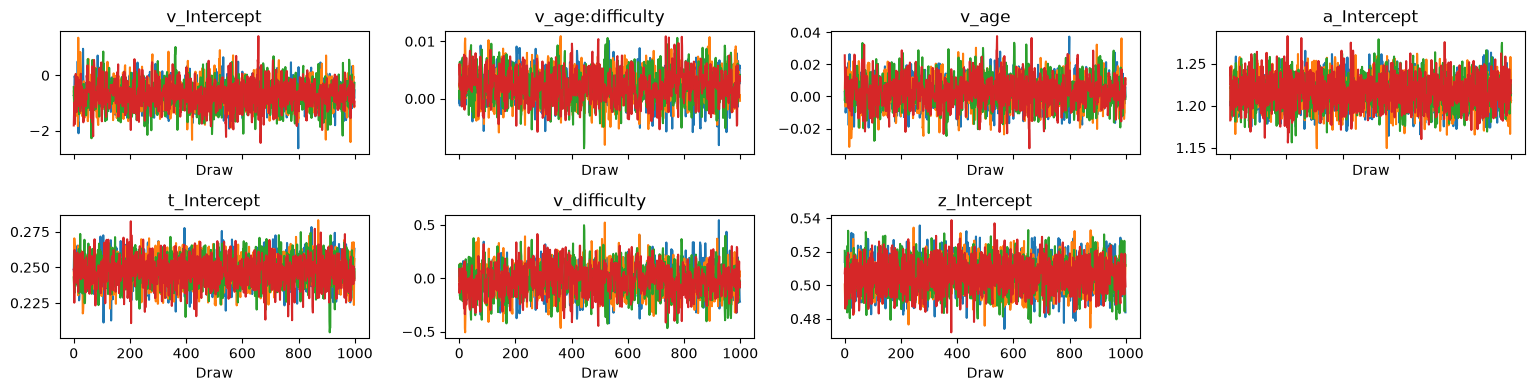

In [36]:
az.plot_trace(idata_C, var_names=["~participant_id"], filter_vars="regex")
plt.tight_layout()

### Step 4: Posterior predictive check

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


Variant C: 20 posterior-predictive draws per chain


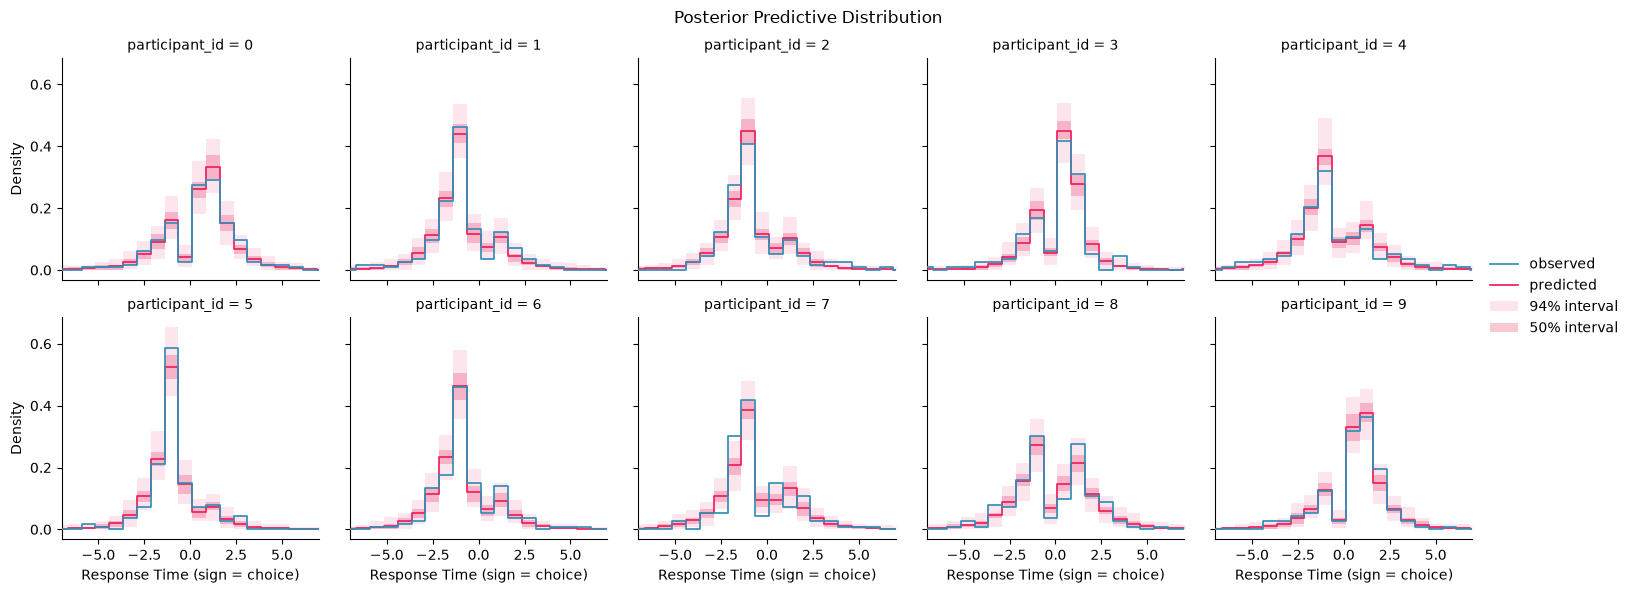

In [37]:
g = hssm.plotting.plot_predictive(
    model_C, n_samples=ppc_samples, col="participant_id", col_wrap=5
)
g.set(xlim=(-7, 7))
validate_predictive("Variant C", model_C)

Variant C: scalar 95% HDI coverage {'v_Intercept': True, 'v_age': True, 'v_difficulty': True, 'v_age:difficulty': True, 'v_1|participant_id_sigma': True, 'v_difficulty|participant_id_sigma': True, 'a_Intercept': True, 'z_Intercept': True, 't_Intercept': True}
Variant C: participant 95% HDI coverage v_1|participant_id=10/10, v_difficulty|participant_id=10/10; overall=20/20


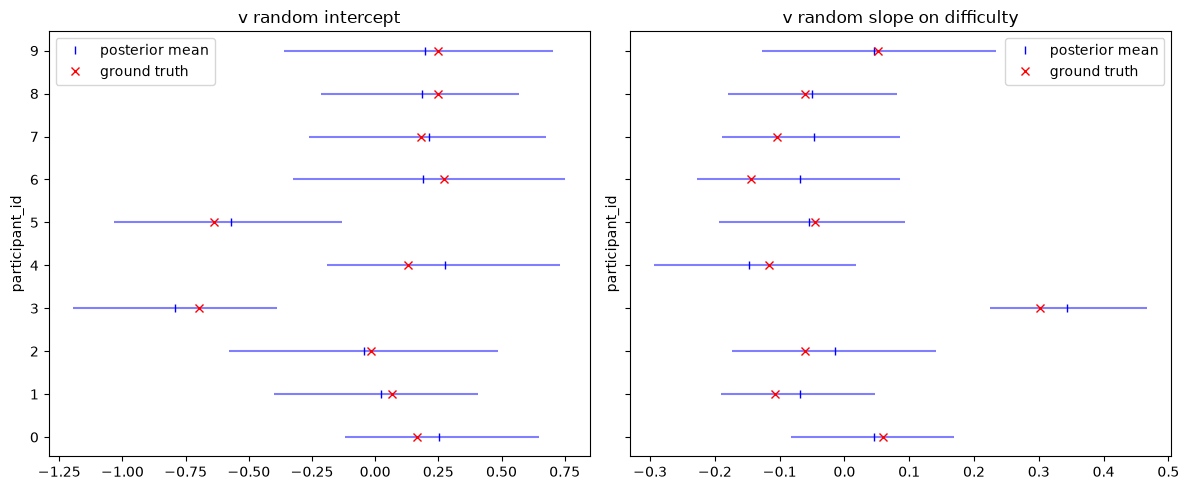

In [38]:
# Participant-wise parameter recovery for v (random intercepts and slopes)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey=True)

for ax, (param_name, truth, label) in zip(
    axes,
    [
        ("v_1|participant_id", v_int_p, "v random intercept"),
        ("v_difficulty|participant_id", v_slope_p, "v random slope on difficulty"),
    ],
):
    post = idata_C.posterior[param_name]
    mean = post.mean(dim=["chain", "draw"]).values
    hdi = az.hdi(post, prob=0.95).values

    yvals = np.arange(n_participants)
    ax.hlines(yvals, hdi[:, 0], hdi[:, 1], color="blue", alpha=0.5)
    ax.plot(mean, yvals, "|", color="blue", label="posterior mean")
    ax.plot(truth, yvals, "x", color="red", label="ground truth")
    ax.set_title(label)
    ax.set_yticks(yvals)
    ax.set_ylabel("participant_id")
    ax.legend()

plt.tight_layout()
validate_recovery(
    "Variant C",
    idata_C,
    scalar_truths={
        "v_Intercept": beta_v_intercept,
        "v_age": beta_v_age,
        "v_difficulty": beta_v_difficulty,
        "v_age:difficulty": beta_v_age_difficulty,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_difficulty|participant_id_sigma": sigma_v_slope,
        "a_Intercept": a_true,
        "z_Intercept": z_true,
        "t_Intercept": t_true,
    },
    required_scalar_names=(
        "v_age",
        "v_difficulty",
        "v_age:difficulty",
        "v_1|participant_id_sigma",
        "v_difficulty|participant_id_sigma",
    ),
    participant_truths={
        "v_1|participant_id": v_int_p,
        "v_difficulty|participant_id": v_slope_p,
    },
)

Text(0.5, 0.98, '')

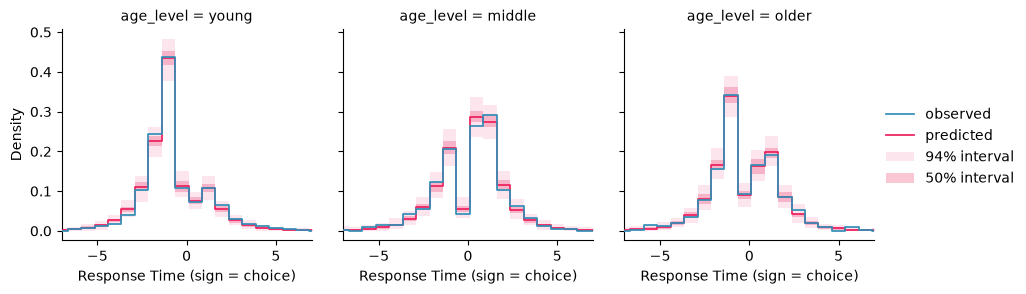

In [39]:
# Posterior predictive: faceted by age level (between-subject factor)
g = hssm.plotting.plot_predictive(
    model_C, n_samples=ppc_samples, col="age_level", col_wrap=3
)
g.set(xlim=(-7, 7))
g.fig.suptitle("")

Text(0.5, 0.98, '')

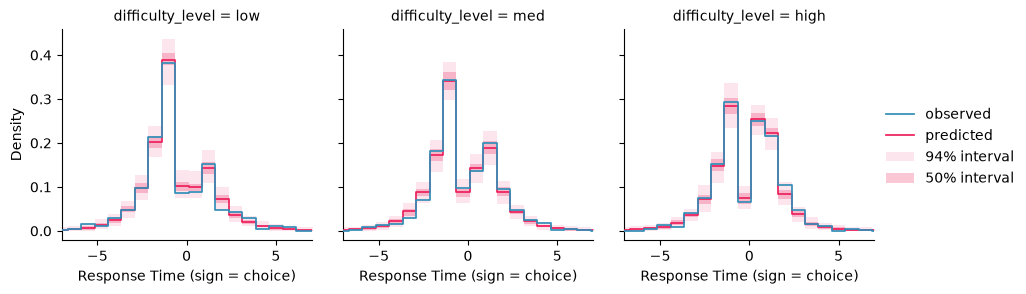

In [40]:
# Posterior predictive: faceted by difficulty level (within-subject factor)
g = hssm.plotting.plot_predictive(
    model_C, n_samples=ppc_samples, col="difficulty_level", col_wrap=3
)
g.set(xlim=(-7, 7))
g.fig.suptitle("")

Text(0.5, 0.98, '')

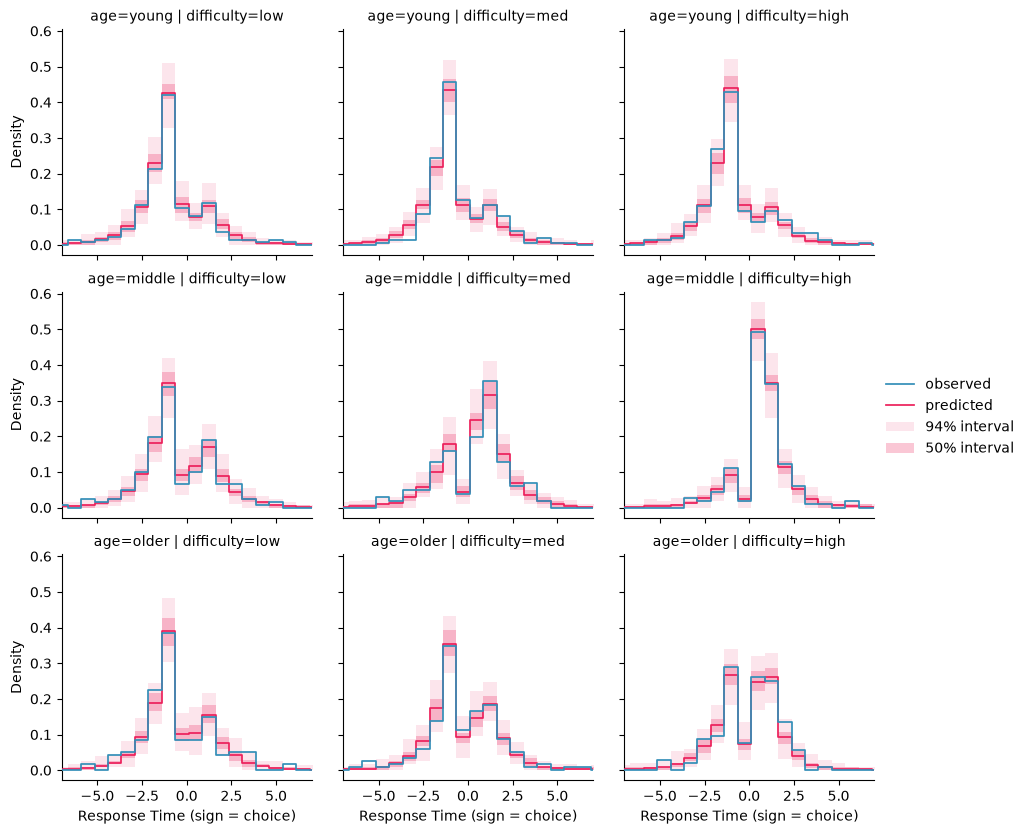

In [41]:
# Posterior predictive: 3x3 interaction grid (age x difficulty)
g = hssm.plotting.plot_predictive(
    model_C,
    n_samples=ppc_samples,
    row="age_level",
    col="difficulty_level",
)
g.set(xlim=(-7, 7))
g.set_titles(template="age={row_name} | difficulty={col_name}")
g.fig.suptitle("")

## Variant D: full hierarchy on every parameter

In Variants A–C we kept `a`, `z`, `t` as global scalars to keep the spotlight on the v regression. In real experiments, however, every DDM parameter usually shows individual differences — some people have higher boundary separations, some have longer non-decision times, etc.

Variant D shows what the **fully hierarchical** case looks like: same v regression as Variant A, but now `global_formula="y ~ 1 + (1 | participant_id)"` adds participant-level random intercepts to **a, z, t** as well. The simulator generates per-participant values for these to match.

This is the most realistic specification for real data, but it's also slower to fit (more parameters to sample).

### Step 1: Simulate the data

Model initialized successfully.


Sampling: [rt,response]


Variant D generator: all free random variables are connected


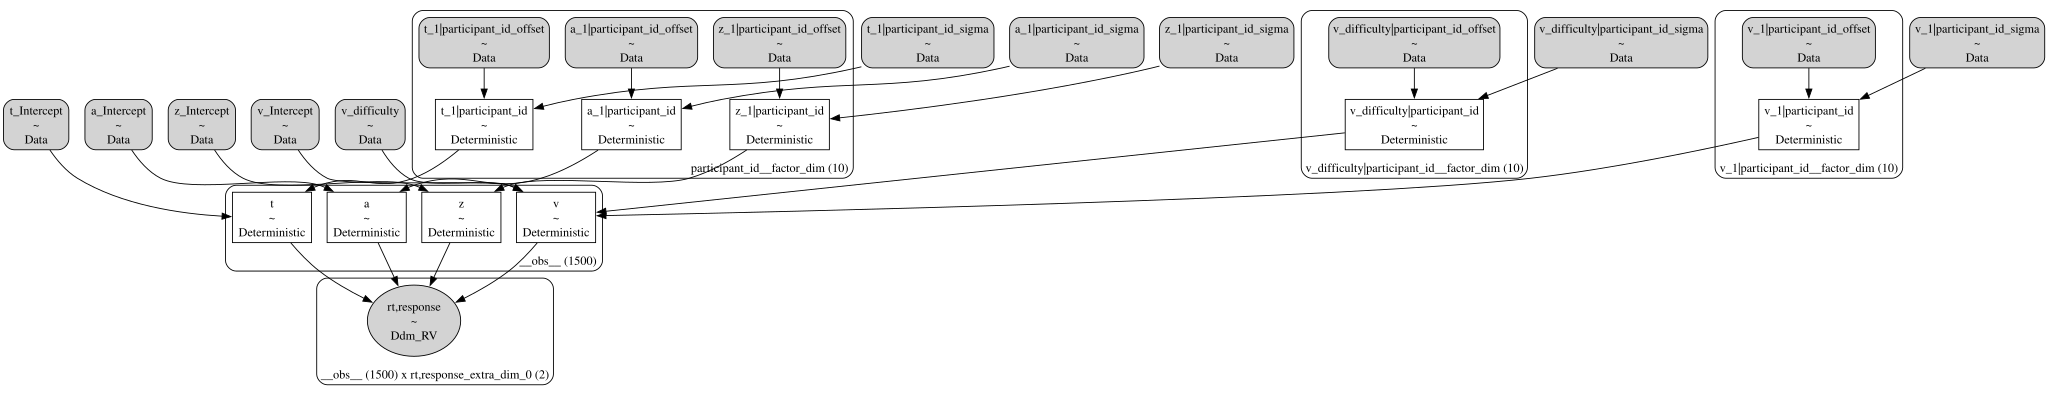

In [42]:
# Variant D: simulate with per-participant a, z, t
beta_v_difficulty = 0.08

rng_D = variant_rngs["D"]
v_int_p = rng_D.normal(0, sigma_v_int, n_participants)
v_slope_p = rng_D.normal(0, sigma_v_slope, n_participants)

# Per-participant a, z, t (centered on the scalar means used in A/B/C)
sigma_a, sigma_z, sigma_t = 0.15, 0.05, 0.05
a_p = a_true + rng_D.normal(0, sigma_a, n_participants)
z_p = np.clip(z_true + rng_D.normal(0, sigma_z, n_participants), 0.05, 0.95)
t_p = np.clip(t_true + rng_D.normal(0, sigma_t, n_participants), 0.001, None)

# Noncentered offsets, derived from the (possibly clipped) per-participant values
v_int_offset = v_int_p / sigma_v_int
v_slope_offset = v_slope_p / sigma_v_slope
a_int_offset = (a_p - a_true) / sigma_a
z_int_offset = (z_p - z_true) / sigma_z
t_int_offset = (t_p - t_true) / sigma_t

# Build HSSM model with full hierarchy
dummy_data = covariates.copy()
dummy_data["rt"] = 1.0
dummy_data["response"] = 1.0

model_D_gen = hssm.HSSM(
    data=dummy_data,
    model="ddm",
    global_formula="y ~ 1 + (1 | participant_id)",
    include=[
        {
            "name": "v",
            "formula": "v ~ 1 + difficulty + (1 + difficulty | participant_id)",
        }
    ],
    noncentered=True,
    initval_jitter=INITVAL_JITTER,
)
assert_connected("Variant D generator", model_D_gen)

# Use do-operator: intervene on every regression coefficient and random effect
synth_idata_D, synth_model_D = model_D_gen.sample_do(
    params={
        "v_Intercept": beta_v_intercept,
        "v_difficulty": beta_v_difficulty,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_1|participant_id_offset": v_int_offset,
        "v_difficulty|participant_id_sigma": sigma_v_slope,
        "v_difficulty|participant_id_offset": v_slope_offset,
        "a_Intercept": a_true,
        "a_1|participant_id_sigma": sigma_a,
        "a_1|participant_id_offset": a_int_offset,
        "z_Intercept": z_true,
        "z_1|participant_id_sigma": sigma_z,
        "z_1|participant_id_offset": z_int_offset,
        "t_Intercept": t_true,
        "t_1|participant_id_sigma": sigma_t,
        "t_1|participant_id_offset": t_int_offset,
    },
    draws=1,
    var_names=["rt,response"],
    return_model=True,
    random_seed=SIMULATION_SEEDS["D"],
)

pm.model_to_graphviz(synth_model_D, var_names=["rt,response"])

In [43]:
synth_df_D = hssm.utils.predictive_dt_to_dataframe(
    synth_idata_D, predictive_group="prior_predictive"
)

data_D = covariates.copy()
data_D["rt"] = synth_df_D["rt"].values
data_D["response"] = synth_df_D["response"].values
assert_two_choices("Variant D", data_D)
data_D.to_csv(SIM_DIR / "sim_variant_D.csv", index=False)
data_D.head()

Variant D: simulated choices [-1.0, 1.0]


,participant_id,difficulty,age,rt,response
0,0,1.285702,56.725679,0.617179,1.0
1,0,4.992779,56.725679,18.008256,-1.0
2,0,6.014984,56.725679,0.990726,-1.0
3,0,0.286890,56.725679,1.392719,1.0
4,0,1.479261,56.725679,0.784103,1.0


### Step 2: Fit a fresh HSSM model

In [44]:
data_D = pd.read_csv(SIM_DIR / "sim_variant_D.csv")

model_D = hssm.HSSM(
    data=data_D,
    model="ddm",
    global_formula="y ~ 1 + (1 | participant_id)",
    include=[
        {
            "name": "v",
            "formula": "v ~ 1 + difficulty + (1 + difficulty | participant_id)",
        }
    ],
    noncentered=True,
    initval_jitter=INITVAL_JITTER,
)
assert_connected("Variant D fitted model", model_D)

Model initialized successfully.


Variant D fitted model: all free random variables are connected


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 1500

Parameters:

v:
    Formula: v ~ 1 + difficulty + (1 + difficulty | participant_id)
    Priors:
        v_Intercept ~ Normal(mu: 2.0, sigma: 3.0)
        v_difficulty ~ Normal(mu: 0.0, sigma: 0.25)
        v_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
        v_difficulty|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Formula: a ~ 1 + (1 | participant_id)
    Priors:
        a_Intercept ~ Gamma(mu: 1.5, sigma: 0.75)
        a_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~ 1 + (1 | participant_id)
    Priors:
        z_Intercept ~ Beta(alpha: 10.0, beta: 10.0)
        z_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: i

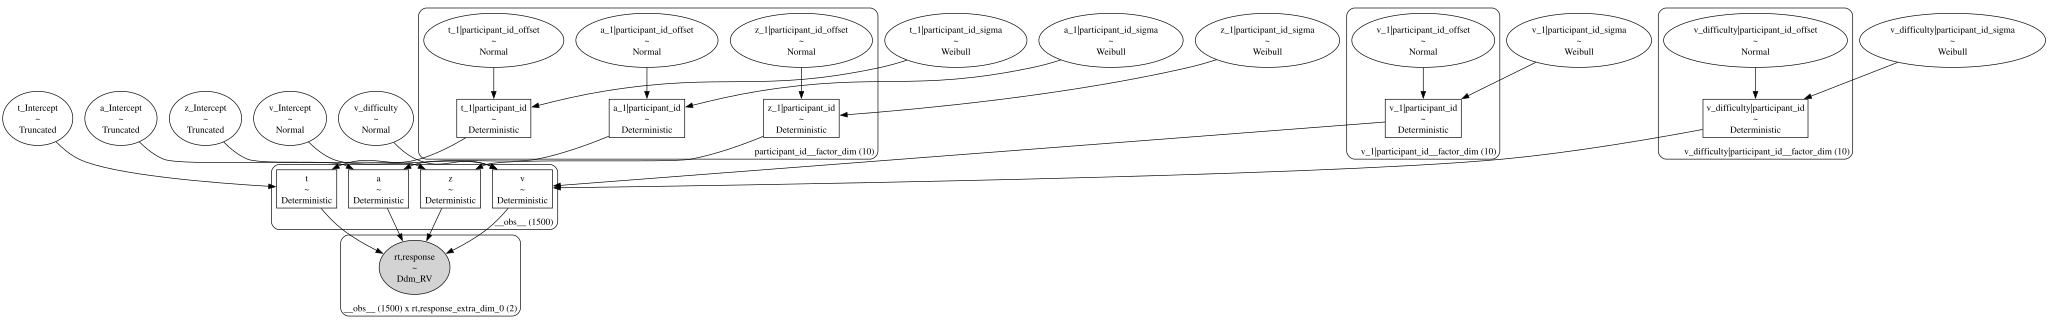

In [45]:
print(model_D)
pm.model_to_graphviz(model_D.pymc_model, var_names=["rt,response"])

In [46]:
idata_D = model_D.sample(
    random_seed=FIT_SEEDS["D"],
    idata_kwargs={"log_likelihood": False},
    **sample_kwargs,
)
validate_sampling("Variant D", idata_D)

Using default initvals. 



Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [v_Intercept, v_difficulty, v_1|participant_id_sigma, v_1|participant_id_offset, v_difficulty|participant_id_sigma, v_difficulty|participant_id_offset, a_Intercept, a_1|participant_id_sigma, a_1|participant_id_offset, z_Intercept, z_1|participant_id_sigma, z_1|participant_id_offset, t_Intercept, t_1|participant_id_sigma, t_1|participant_id_offset]


Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 169 seconds.


Variant D: divergences=0 (0.000%), max r_hat=1.0034, min bulk/tail ESS=838/1045


### Step 3: Inspect what got estimated

In [47]:
az.summary(idata_D)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_Intercept,-0.296,0.108,-0.47,-0.12,3311,2885,1.00,0.0019,0.0015
t_1|participant_id_sigma,0.079,0.026,0.046,0.12,2105,2285,1.00,0.00058,0.00078
a_1|participant_id_sigma,0.229,0.061,0.15,0.34,1944,2491,1.00,0.0013,0.0014
a_1|participant_id[0],-0.186,0.085,-0.32,-0.053,1610,2304,1.00,0.0021,0.0016
a_1|participant_id[1],0.166,0.099,0.01,0.33,2000,2332,1.00,0.0022,0.0017
a_1|participant_id[2],-0.233,0.085,-0.37,-0.099,1598,2265,1.00,0.0021,0.0017
a_1|participant_id[3],0.235,0.1,0.078,0.4,1941,2863,1.00,0.0023,0.0017
a_1|participant_id[4],0.117,0.104,-0.042,0.28,2145,2924,1.00,0.0022,0.0017
a_1|participant_id[5],0.269,0.094,0.12,0.42,1797,2692,1.00,0.0022,0.0018
a_1|participant_id[6],0.001,0.09,-0.14,0.14,1514,2256,1.00,0.0023,0.0018


In [48]:
az.summary(idata_D, var_names=["~participant_id"], filter_vars="regex")

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_Intercept,-0.296,0.108,-0.47,-0.12,3311,2885,1.00,0.0019,0.0015
a_Intercept,1.177,0.076,1.1,1.3,1270,1609,1.00,0.0021,0.0018
t_Intercept,0.224,0.029,0.18,0.27,1745,1921,1.00,0.00071,0.00061
v_difficulty,0.09,0.061,-0.007,0.18,838,1044,1.00,0.0021,0.002
z_Intercept,0.5214,0.017,0.49,0.55,3434,2729,1.00,0.0003,0.00028


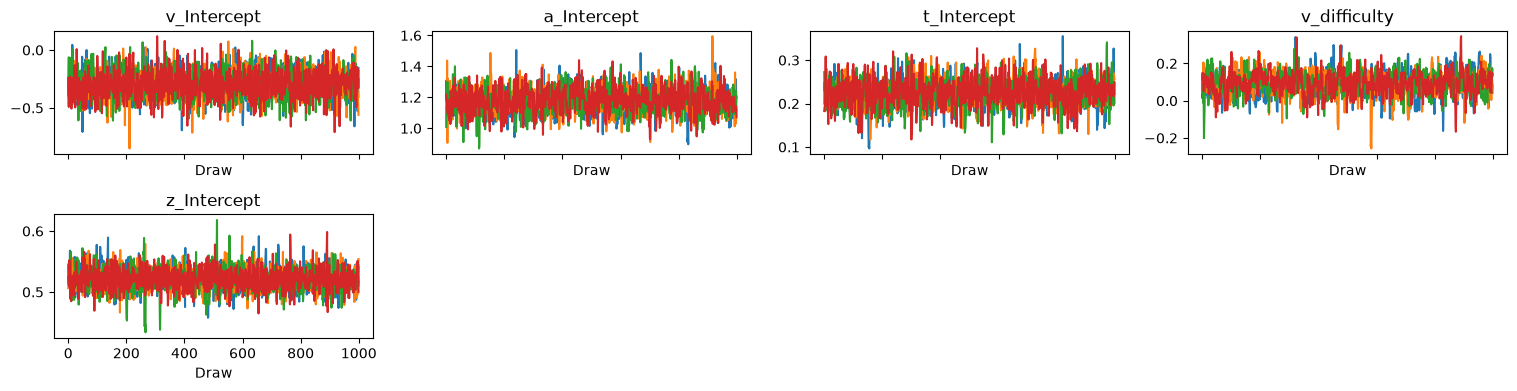

In [49]:
az.plot_trace(idata_D, var_names=["~participant_id"], filter_vars="regex")
plt.tight_layout()

### Step 4: Posterior predictive check

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


Variant D: 20 posterior-predictive draws per chain


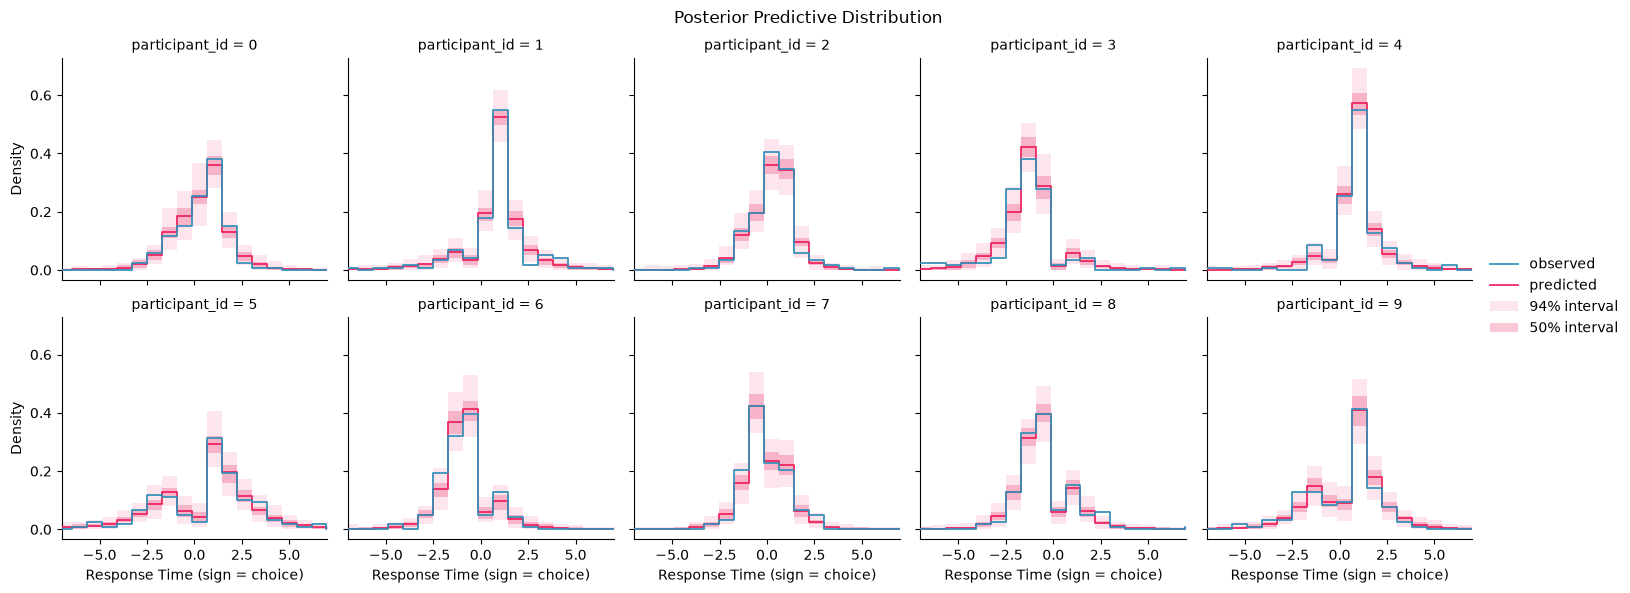

In [50]:
g = hssm.plotting.plot_predictive(
    model_D, n_samples=ppc_samples, col="participant_id", col_wrap=5
)
g.set(xlim=(-7, 7))
validate_predictive("Variant D", model_D)

Variant D: scalar 95% HDI coverage {'v_Intercept': False, 'v_difficulty': True, 'v_1|participant_id_sigma': True, 'v_difficulty|participant_id_sigma': True, 'a_Intercept': True, 'a_1|participant_id_sigma': True, 'z_Intercept': True, 'z_1|participant_id_sigma': True, 't_Intercept': True, 't_1|participant_id_sigma': True}
Variant D: participant 95% HDI coverage v_1|participant_id=9/10, v_difficulty|participant_id=10/10, a_1|participant_id=10/10, z_1|participant_id=8/10, t_1|participant_id=10/10; overall=47/50


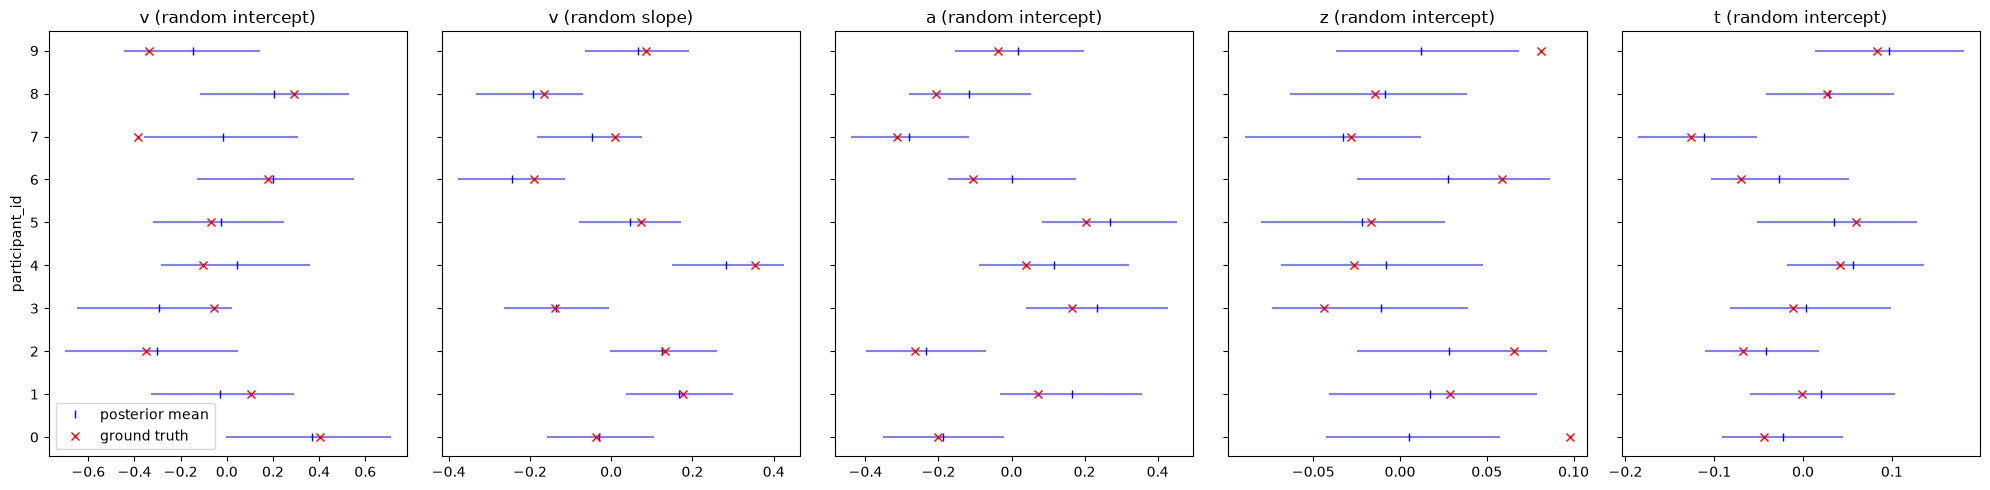

In [51]:
# Participant-wise parameter recovery for all DDM parameters
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 5), sharey=True)

for ax, (param_name, truth, label) in zip(
    axes,
    [
        ("v_1|participant_id", v_int_p, "v (random intercept)"),
        ("v_difficulty|participant_id", v_slope_p, "v (random slope)"),
        ("a_1|participant_id", a_p - a_true, "a (random intercept)"),
        ("z_1|participant_id", z_p - z_true, "z (random intercept)"),
        ("t_1|participant_id", t_p - t_true, "t (random intercept)"),
    ],
):
    post = idata_D.posterior[param_name]
    mean = post.mean(dim=["chain", "draw"]).values
    hdi = az.hdi(post, prob=0.95).values

    yvals = np.arange(n_participants)
    ax.hlines(yvals, hdi[:, 0], hdi[:, 1], color="blue", alpha=0.5)
    ax.plot(mean, yvals, "|", color="blue", label="posterior mean")
    ax.plot(truth, yvals, "x", color="red", label="ground truth")
    ax.set_title(label)
    ax.set_yticks(yvals)
    if ax is axes[0]:
        ax.set_ylabel("participant_id")
        ax.legend()

plt.tight_layout()
validate_recovery(
    "Variant D",
    idata_D,
    scalar_truths={
        "v_Intercept": beta_v_intercept,
        "v_difficulty": beta_v_difficulty,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_difficulty|participant_id_sigma": sigma_v_slope,
        "a_Intercept": a_true,
        "a_1|participant_id_sigma": sigma_a,
        "z_Intercept": z_true,
        "z_1|participant_id_sigma": sigma_z,
        "t_Intercept": t_true,
        "t_1|participant_id_sigma": sigma_t,
    },
    required_scalar_names=(
        "v_difficulty",
        "v_1|participant_id_sigma",
        "v_difficulty|participant_id_sigma",
        "a_1|participant_id_sigma",
        "z_1|participant_id_sigma",
        "t_1|participant_id_sigma",
    ),
    participant_truths={
        "v_1|participant_id": v_int_p,
        "v_difficulty|participant_id": v_slope_p,
        "a_1|participant_id": a_p - a_true,
        "z_1|participant_id": z_p - z_true,
        "t_1|participant_id": t_p - t_true,
    },
)